# 6. Linear regression and regularisation

Linear regression is the oldest supervised learning method and still the most used one. It
is worth studying in depth for three reasons. It is *interpretable*: each coefficient says
how much the prediction changes when one feature changes. It is *the prototype*: the
notation, the loss, the two ways of fitting (a closed form and gradient descent), the
diagnostics and the regularisation ideas all carry over to logistic regression (notebook 7) and
support vector machines (notebook 11), which are
"linear regression plus something". And it is *often good enough*: with well-engineered
features (notebook 4) a regularised linear model is a strong baseline on most tabular
problems.

We derive the normal equations and their geometry, implement least squares from scratch
in three ways (solver, gradient descent, stochastic gradient descent) and verify them
against scikit-learn, learn to read coefficients and residual diagnostics, meet the
regression metrics, and then spend the second half on **regularisation** — ridge, lasso and
elastic net — which gives us a direct handle on the bias–variance trade-off of notebook 5.
A short introduction to generalised linear models follows, and the notebook closes with the
three sections you will come back to in practice: an honest account of what each estimator
is good and bad at (with its failure modes demonstrated, section 9), a visual guide to
tuning the penalty and the feature basis (section 10), and a complete case study on real
patient data (section 11).

**Prerequisites:** notebooks 2 (linear algebra, gradients, maximum likelihood), 4
(pipelines, scaling) and 5 (cross-validation, bias–variance).

## Learning objectives

After working through this notebook you will be able to

- state the linear model and its assumptions, derive the normal equations from the squared loss and interpret the solution as an orthogonal projection;
- fit a linear regression with `np.linalg.lstsq`, with batch and stochastic gradient descent, and with `LinearRegression`, and explain when each solver is appropriate;
- explain why feature scaling changes the *conditioning* of the problem and hence the speed of gradient descent;
- interpret raw and standardised coefficients, attach bootstrap or analytic confidence intervals to them, and detect multicollinearity with the variance inflation factor;
- read residual, Q–Q and leverage plots to diagnose non-linearity, heteroscedasticity and influential points;
- choose among MSE, RMSE, MAE, MAPE, $R^2$ and adjusted $R^2$, and use robust regression when outliers are present;
- extend linear models with polynomial, spline and interaction features;
- derive ridge regression in closed form, explain lasso sparsity through soft thresholding and the geometry of the $\ell_1$ ball, and choose the regularisation strength by cross-validation;
- fit a Poisson regression and place linear and logistic regression in the family of generalised linear models;
- say what least squares, ridge, lasso and elastic net each assume, where each one breaks, and which to reach for on a given dataset;
- tune `alpha`, `l1_ratio` and the feature basis with validation curves, 2-D cross-validation heat-maps and the one-standard-error rule;
- carry a real regression problem end to end — baseline, pipeline, model comparison, tuning, residual diagnostics, coefficients in the original units — and report the result honestly to a non-technical stakeholder.

## Setup

In [1]:
import time              # time.time() and time.perf_counter() measure run times

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns    # statistical plots on top of matplotlib (not used in this notebook)
from scipy import stats  # SciPy statistics: the t distribution for p-values, normal Q-Q plots

# course helpers: set_style() applies the shared plot style, PALETTE is the list of course colours,
# load_california_housing() returns the California housing data (or a synthetic stand-in when offline)
from course_utils import set_style, PALETTE, load_california_housing

RANDOM_STATE = 42                          # one fixed seed so every run gives the same results
rng = np.random.default_rng(RANDOM_STATE)  # a seeded NumPy random-number generator
set_style()                                # apply the course-wide matplotlib settings once

## 1. The linear model

### 1.1 Model and assumptions

A linear regression model predicts a real-valued target as a weighted sum of the features
plus an intercept:

$$
\hat{y} \;=\; f(\mathbf{x}; \mathbf{w}, b) \;=\; \mathbf{w}^\top \mathbf{x} + b \;=\; b + w_1 x_1 + \dots + w_d x_d .
$$

It is *linear in the parameters* $\mathbf{w}$, not necessarily in the raw inputs: $x_2$ may be
the square of $x_1$, a log, an interaction — the model does not care (section 6). Writing
$\boldsymbol{\theta} = (b, w_1, \dots, w_d)$ and prepending a column of ones to the design
matrix, $\mathbf{X} \in \mathbb{R}^{n \times (d+1)}$, all $n$ predictions at once are
$\hat{\mathbf{y}} = \mathbf{X}\boldsymbol{\theta}$.

The statistical model behind it is $y = \mathbf{w}^\top\mathbf{x} + b + \varepsilon$ with
noise $\varepsilon$ of mean zero. The classical assumptions — needed for the *inference*
results of section 3, not for prediction — are: (i) the relationship is linear in the
chosen features, (ii) errors are independent, (iii) errors have constant variance
(*homoscedasticity*), (iv) errors are Gaussian, and (v) no feature is an exact linear
combination of the others. Section 4 shows how to check them.

**Squared loss and maximum likelihood.** We fit by minimising the mean squared error

$$
\mathcal{L}(\boldsymbol{\theta}) \;=\; \frac{1}{n} \sum_{i=1}^n \big(y_i - \mathbf{x}_i^\top \boldsymbol{\theta}\big)^2
\;=\; \frac{1}{n}\,\|\mathbf{y} - \mathbf{X}\boldsymbol{\theta}\|_2^2 .
$$

Notebook 2 (section 4) showed that this is exactly maximum likelihood under Gaussian noise:
$\log p(\mathbf{y} \mid \mathbf{X}, \boldsymbol{\theta}) = -\frac{1}{2\sigma^2}\|\mathbf{y} - \mathbf{X}\boldsymbol{\theta}\|^2 + \text{const}$,
so the least-squares estimate is the MLE. That is the justification for the square — and
the reason least squares is sensitive to outliers (section 5.2): a Gaussian likelihood
regards a residual of 10 standard deviations as essentially impossible and bends the line
to avoid it.

> **History.** Least squares was published by Legendre (1805) for fitting orbits of
> comets; Gauss claimed to have used it since 1795 and gave the probabilistic
> justification. Stigler (1981) tells the story of the priority dispute.

Our first dataset is the **diabetes** data of Efron et al. (2004): 442 patients, 10 baseline
variables (age, sex, body-mass index, blood pressure and six blood serum measurements), and
a target measuring disease progression one year later. We load it in raw units
(`scaled=False`) so that coefficients have interpretable units.

In [2]:
from sklearn.datasets import load_diabetes     # the diabetes dataset that ships with scikit-learn

# scaled=False keeps the original units (by default scikit-learn centres and rescales every column);
# as_frame=True returns pandas objects: .data is a DataFrame of shape (442, 10), .target a Series (442,)
diabetes = load_diabetes(scaled=False, as_frame=True)
X_diab, y_diab = diabetes.data, diabetes.target
feature_names = list(X_diab.columns)
print(f"{X_diab.shape[0]} patients, {X_diab.shape[1]} features; target: mean {y_diab.mean():.1f}, std {y_diab.std():.1f}")
X_diab.describe().T[["mean", "std", "min", "max"]].round(2)    # one row per feature, four summary statistics

442 patients, 10 features; target: mean 152.1, std 77.1


,mean,std,min,max
age,48.52,13.11,19.00,79.00
sex,1.47,0.50,1.00,2.00
bmi,26.38,4.42,18.00,42.20
bp,94.65,13.83,62.00,133.00
s1,189.14,34.61,97.00,301.00
s2,115.44,30.41,41.60,242.40
s3,49.79,12.93,22.00,99.00
s4,4.07,1.29,2.00,9.09
s5,4.64,0.52,3.26,6.11
s6,91.26,11.50,58.00,124.00


### 1.2 Geometry: least squares is a projection

Consider the target vector $\mathbf{y} \in \mathbb{R}^n$ and the *column space* of
$\mathbf{X}$ — all vectors of the form $\mathbf{X}\boldsymbol{\theta}$, a $(d+1)$-dimensional
subspace of $\mathbb{R}^n$. Minimising $\|\mathbf{y} - \mathbf{X}\boldsymbol{\theta}\|$ means
finding the point of that subspace closest to $\mathbf{y}$, which is the **orthogonal
projection** of $\mathbf{y}$ onto it. The residual $\mathbf{r} = \mathbf{y} - \mathbf{X}\hat{\boldsymbol{\theta}}$
must therefore be orthogonal to every column of $\mathbf{X}$:

$$
\mathbf{X}^\top \big(\mathbf{y} - \mathbf{X}\hat{\boldsymbol{\theta}}\big) = \mathbf{0}
\quad\Longleftrightarrow\quad
\mathbf{X}^\top\mathbf{X}\,\hat{\boldsymbol{\theta}} = \mathbf{X}^\top\mathbf{y}.
$$

These are the **normal equations** ("normal" = perpendicular). The same equations follow
from calculus: the gradient of the loss is
$\nabla_{\boldsymbol{\theta}} \mathcal{L} = \frac{2}{n}\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y})$
(derived in notebook 2, section 2), and setting it to zero gives the same linear system. Two
consequences of the projection picture are worth remembering: the residuals always have
mean zero and are uncorrelated with every feature (because the intercept column and the
feature columns are all orthogonal to $\mathbf{r}$), and the fitted values
$\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}$ with the **hat matrix**
$\mathbf{H} = \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$ will return in the
leverage diagnostics of section 4.

In [3]:
def add_intercept(X):
    """Prepend a column of ones: theta = (b, w_1, ..., w_d).

    Takes an (n, d) array or DataFrame and returns an (n, d + 1) float array whose first column is all ones,
    so that the first coefficient plays the role of the intercept b.
    """
    X = np.asarray(X, dtype=float)              # DataFrame -> float NumPy array
    return np.c_[np.ones(len(X)), X]            # np.c_[...] puts its arguments side by side as columns

Xd = add_intercept(X_diab)               # the design matrix, shape (442, 11)
yd = y_diab.to_numpy()                   # the target as a NumPy array, shape (442,)
# np.linalg.lstsq minimises ||Xd theta - yd||^2 and returns (solution, residual sum, rank, singular values);
# `theta_hat, *_ =` keeps the first item and discards the rest; rcond=None uses the recommended cut-off below which
# singular values count as zero
theta_hat, *_ = np.linalg.lstsq(Xd, yd, rcond=None)
residuals = yd - Xd @ theta_hat          # @ is matrix multiplication; Xd @ theta_hat are the fitted values
print("coefficients (intercept, then features):", theta_hat.round(3))
# both numbers should be ~0: the residuals have mean zero and are orthogonal to every column (X^T r = 0)
print(f"mean residual = {residuals.mean():.2e};  max |X^T r| = {np.abs(Xd.T @ residuals).max():.2e}  (orthogonality)")
# R^2 = 1 - RSS / TSS; r @ r (a dot product of r with itself) is the sum of squared residuals
print(f"R^2 on the training data = {1 - residuals @ residuals / ((yd - yd.mean()) @ (yd - yd.mean())):.3f}")

coefficients (intercept, then features): [-3.34567e+02 -3.60000e-02 -2.28600e+01  5.60300e+00  1.11700e+00
 -1.09000e+00  7.46000e-01  3.72000e-01  6.53400e+00  6.84830e+01
  2.80000e-01]
mean residual = 7.62e-13;  max |X^T r| = 6.64e-08  (orthogonality)
R^2 on the training data = 0.518


The residual is orthogonal to all eleven columns to machine precision. $R^2 = 0.52$: the ten
baseline variables explain about half of the variance of disease progression — a noisy
problem, as we will see repeatedly.

## 2. Solving the normal equations

### 2.1 Direct solvers

The normal equations are a $(d+1) \times (d+1)$ linear system. Three ways to solve them:

1. **Invert:** $\hat{\boldsymbol{\theta}} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$ —
   the textbook formula; never compute the inverse in practice (slower and less accurate).
2. **Solve:** `np.linalg.solve(X.T @ X, X.T @ y)` — a Cholesky or LU factorisation of the
   $(d+1)\times(d+1)$ matrix. Cost $O(nd^2)$ to form $\mathbf{X}^\top\mathbf{X}$ plus $O(d^3)$
   to solve. Fails if $\mathbf{X}^\top\mathbf{X}$ is singular (collinear features).
3. **Least-squares solver:** `np.linalg.lstsq(X, y)` — works on $\mathbf{X}$ directly through
   a QR or SVD factorisation, is numerically more stable (it never squares the condition
   number, see 2.3) and returns the minimum-norm solution when the system is singular.
   scikit-learn's `LinearRegression` uses this.

In [4]:
from sklearn.linear_model import LinearRegression     # ordinary least squares

# solve the normal equations (X^T X) theta = X^T y directly (np.linalg.solve uses an LU factorisation)
theta_solve = np.linalg.solve(Xd.T @ Xd, Xd.T @ yd)
theta_lstsq, *_ = np.linalg.lstsq(Xd, yd, rcond=None)    # works on X itself and never forms X^T X
sk = LinearRegression().fit(X_diab, y_diab)               # fits the intercept itself, so no column of ones is needed
theta_sk = np.r_[sk.intercept_, sk.coef_]                 # np.r_[...] joins into one 1-D array (b, w_1, ..., w_d)
print(f"max |solve - lstsq|         = {np.abs(theta_solve - theta_lstsq).max():.2e}")
print(f"max |lstsq - LinearRegression| = {np.abs(theta_lstsq - theta_sk).max():.2e}")

max |solve - lstsq|         = 4.80e-10
max |lstsq - LinearRegression| = 9.66e-13


All three agree to about $10^{-10}$; the tiny differences are floating-point rounding. For
$n$ up to millions and $d$ up to a few thousand, a direct solver is the right tool: exact,
one pass over the data, no hyper-parameters.

### 2.2 Gradient descent from scratch

When $d$ is very large, when the data do not fit in memory, or when the model is not linear
(neural networks), we fall back to **gradient descent** (notebook 2, section 2): start
anywhere and repeatedly step against the gradient,

$$
\boldsymbol{\theta} \;\leftarrow\; \boldsymbol{\theta} - \eta\, \nabla_{\boldsymbol{\theta}}\mathcal{L}
\;=\; \boldsymbol{\theta} - \eta\,\frac{2}{n}\,\mathbf{X}^\top(\mathbf{X}\boldsymbol{\theta} - \mathbf{y}),
$$

with learning rate $\eta$. Three variants differ in how much data each step uses:

- **Batch GD** uses all $n$ rows per step: exact gradient, $O(nd)$ per step.
- **Stochastic GD (SGD)** uses one random row per step: a noisy gradient that is $n$ times
  cheaper; the noise never settles unless $\eta$ is decreased (Robbins & Monro, 1951).
- **Mini-batch GD** uses a random batch of $m$ rows (32–512): the practical compromise and
  the workhorse of deep learning.

We standardise the features first — section 2.3 shows why this is not optional — and write
a small class in the scikit-learn style. One *epoch* is one pass over the data.

batch GD (eta = 0.1)                 final MSE  2867.70   max |w - w_OLS| =  21.70   (0.02 s)
mini-batch GD, m = 32 (eta = 0.05)   final MSE  2872.61   max |w - w_OLS| =   2.48   (0.08 s)
SGD, m = 1 (eta = 0.005)             final MSE  2951.03   max |w - w_OLS| =   4.05   (1.87 s)
least-squares optimum                MSE        2859.70


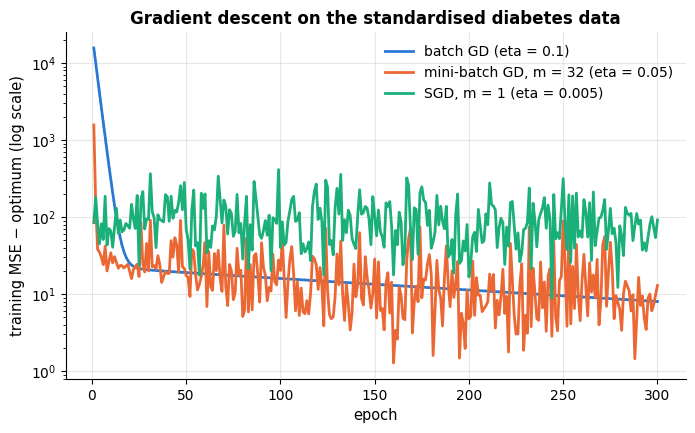

In [5]:
from sklearn.preprocessing import StandardScaler       # rescales each column to mean 0 and standard deviation 1


class LinearRegressionGD:
    """Linear regression by (mini-batch) gradient descent on the mean squared error.

    learning_rate   step size eta
    n_epochs        number of passes over the data
    batch_size      rows per update: None = all rows (batch GD), 1 = stochastic GD, m = mini-batches of about m rows
    random_state    seed for the row shuffling in every epoch
    After fit(): w_ (weights), b_ (intercept) and loss_history_ (training MSE after each epoch).
    """

    def __init__(self, learning_rate=0.1, n_epochs=100, batch_size=None, random_state=RANDOM_STATE):
        """Store the settings; nothing is computed until fit()."""
        # tuple assignment: the four attributes receive the four arguments in order
        self.learning_rate, self.n_epochs, self.batch_size, self.random_state = learning_rate, n_epochs, batch_size, random_state

    def fit(self, X, y):
        """Run gradient descent from w = 0, b = 0 on X of shape (n, d) and y of shape (n,); returns self."""
        X, y = np.asarray(X, dtype=float), np.asarray(y, dtype=float)
        n, d = X.shape
        gen = np.random.default_rng(self.random_state)      # a private generator: identical shuffles on every fit
        self.w_, self.b_ = np.zeros(d), 0.0
        self.loss_history_ = []
        batch = n if self.batch_size is None else self.batch_size
        for _ in range(self.n_epochs):
            # gen.permutation(n) shuffles the row indices; np.array_split cuts them into n // batch nearly equal chunks
            # (max(1, ...) guarantees at least one); each chunk idx holds the rows of one update
            for idx in np.array_split(gen.permutation(n), max(1, n // batch)):
                error = X[idx] @ self.w_ + self.b_ - y[idx]           # (m,)  residuals of the batch
                # step against the batch gradient of the MSE: (2/m) X_batch^T error for w, 2 * mean(error) for b
                self.w_ -= self.learning_rate * 2 * X[idx].T @ error / len(idx)   # gradient w.r.t. w
                self.b_ -= self.learning_rate * 2 * error.mean()                   # gradient w.r.t. b
            self.loss_history_.append(np.mean((X @ self.w_ + self.b_ - y) ** 2))   # MSE on all rows after the epoch
        return self

    def predict(self, X):
        """Return the predictions X @ w_ + b_ for the rows of X."""
        return np.asarray(X, dtype=float) @ self.w_ + self.b_


scaler = StandardScaler().fit(X_diab)
Xs = scaler.transform(X_diab)                  # standardised features as a NumPy array, shape (442, 10)
ols_scaled = LinearRegression().fit(Xs, yd)    # the exact least-squares solution on the same features, as reference
mse_optimal = np.mean((ols_scaled.predict(Xs) - yd) ** 2)     # the lowest training MSE a linear model can reach

variants = {
    "batch GD (eta = 0.1)": LinearRegressionGD(learning_rate=0.1, n_epochs=300),
    "mini-batch GD, m = 32 (eta = 0.05)": LinearRegressionGD(learning_rate=0.05, n_epochs=300, batch_size=32),
    "SGD, m = 1 (eta = 0.005)": LinearRegressionGD(learning_rate=0.005, n_epochs=300, batch_size=1),
}
fig, ax = plt.subplots(figsize=(8, 4.5))
for name, model in variants.items():
    t0 = time.time()                       # wall-clock time in seconds
    model.fit(Xs, yd)
    ax.plot(np.arange(1, 301), np.array(model.loss_history_) - mse_optimal, label=name)   # epochs numbered 1..300
    # :36s pads the name to 36 characters, :8.2f is width 8 with 2 decimals; loss_history_[-1] is the last epoch
    print(f"{name:36s} final MSE {model.loss_history_[-1]:8.2f}   max |w - w_OLS| = {np.abs(model.w_ - ols_scaled.coef_).max():6.2f}   ({time.time() - t0:.2f} s)")
print(f"{'least-squares optimum':36s} MSE       {mse_optimal:8.2f}")
ax.set_yscale("log")
ax.set_xlabel("epoch")
ax.set_ylabel("training MSE − optimum (log scale)")
ax.set_title("Gradient descent on the standardised diabetes data")
ax.legend()
plt.show()

All variants approach the least-squares optimum. Batch GD descends smoothly; mini-batch GD
makes many more updates per epoch and gets close faster; pure SGD is fastest per epoch in
principle but noisy, and its loss keeps fluctuating around the optimum. Notice also that
the *loss* is within a few units of the optimum long before the *coefficients* are: the
slowest direction of the problem is nearly flat (several serum measurements are strongly
correlated — section 4.2), so many different coefficient vectors give almost the same loss.

### 2.3 Learning rate, scaling and conditioning

For a quadratic loss, gradient descent with a fixed step converges if and only if
$\eta < 2/L$, where $L = 2\lambda_{\max}(\mathbf{X}^\top\mathbf{X}/n)$ is the largest
curvature of the loss; and the *rate* of convergence is governed by the **condition
number** $\kappa = \lambda_{\max}/\lambda_{\min}$ of $\mathbf{X}^\top\mathbf{X}$: the error
shrinks by a factor of about $(1 - 1/\kappa)$ per step in the flattest direction, so the
number of steps needed grows linearly with $\kappa$ (Boyd & Vandenberghe, 2004, chapter 9).
Features on different scales produce a huge $\kappa$ — the loss surface is a long, thin
valley, and a step small enough to be stable across the valley barely moves along it.

raw features           condition number =      76279.0   max stable learning rate = 4.87e-04
standardised features  condition number =        470.1   max stable learning rate = 2.48e-01


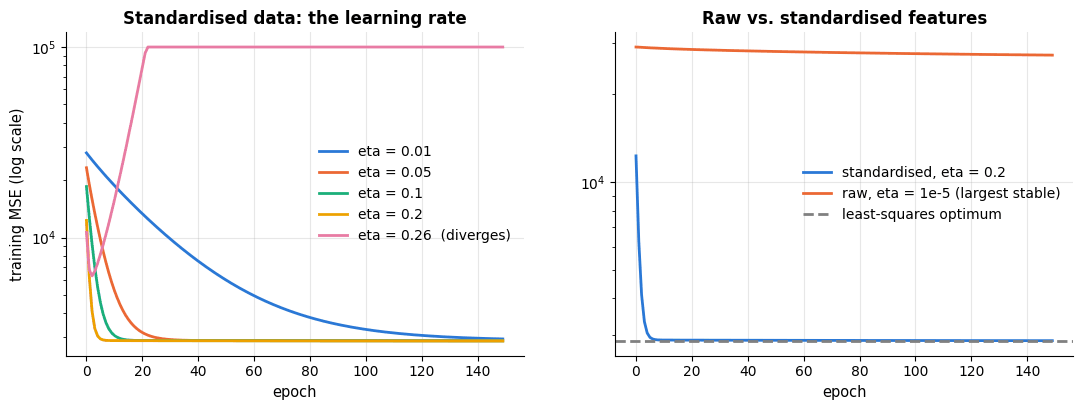

In [6]:
# centre the raw columns (subtract each column's mean), so that they differ from Xs only in their scales
Xd_raw_centered = X_diab.to_numpy() - X_diab.to_numpy().mean(0)
for label, M in [("raw features", Xd_raw_centered), ("standardised features", Xs)]:
    # np.linalg.eigvalsh returns the eigenvalues of a symmetric matrix (here X^T X / n) in ascending order
    eig = np.linalg.eigvalsh(M.T @ M / len(M))
    # condition number = largest / smallest eigenvalue; GD is stable for eta < 2 / L = 1 / lambda_max (section 2.3)
    print(f"{label:22s} condition number = {eig.max() / eig.min():12.1f}   max stable learning rate = {1 / eig.max():.2e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for eta in [0.01, 0.05, 0.1, 0.2, 0.26]:
    h = np.array(LinearRegressionGD(learning_rate=eta, n_epochs=150).fit(Xs, yd).loss_history_)   # MSE per epoch
    # np.minimum caps a diverging curve at 1e5 to keep the plot readable; the label marks the runs that blew up
    axes[0].plot(np.minimum(h, 1e5), label=f"eta = {eta}" + ("  (diverges)" if h[-1] > 1e5 else ""))
axes[0].set_yscale("log")
axes[0].set_title("Standardised data: the learning rate")
axes[0].set_xlabel("epoch")
axes[0].set_ylabel("training MSE (log scale)")
axes[0].legend()
# the same model on standardised and on raw (centred) features, each with its own learning rate
for label, M, eta in [("standardised, eta = 0.2", Xs, 0.2), ("raw, eta = 1e-5 (largest stable)", Xd_raw_centered, 1e-5)]:
    h = LinearRegressionGD(learning_rate=eta, n_epochs=150).fit(M, yd).loss_history_
    axes[1].plot(h, label=label)
axes[1].axhline(mse_optimal, color="gray", ls="--", label="least-squares optimum")
axes[1].set_yscale("log")
axes[1].set_title("Raw vs. standardised features")
axes[1].set_xlabel("epoch")
axes[1].legend()
plt.show()

The left panel shows the learning-rate dilemma: too small is slow, too large oscillates, and
above the threshold $2/L \approx 0.25$ the iteration diverges. The right panel is the reason
notebook 4 insisted on scaling: on the raw features (ages in years, serum measures in the
hundreds) the condition number is about $10^5$ times larger, the largest stable learning
rate is $10^{-5}$, and 150 epochs achieve essentially nothing. Standardisation is a free
change of coordinates that makes the valley round.

> **Practical guidance.** Use a direct solver (`LinearRegression`, `Ridge`) whenever the
> data fit in memory and $d$ is at most a few thousand: it is exact and needs no tuning.
> Use `SGDRegressor` or mini-batch GD for very large $n$ or streaming data, always on
> standardised features, and prefer adaptive step sizes (`learning_rate="invscaling"`,
> or `"adaptive"`). Everything you learned here about $\eta$ and conditioning applies
> unchanged to logistic regression and neural networks.

## 3. Interpreting the coefficients

### 3.1 Units and standardised coefficients

A coefficient $w_j$ is the change in the predicted target for a one-unit increase of $x_j$,
*holding the other features fixed*. Its value depends on the unit of $x_j$: the `bmi`
coefficient of about 5.6 means "+5.6 progression points per kg/m²", whereas the `age`
coefficient near zero means that, once the other measurements are known, age adds little.
To compare features on a common footing, fit on standardised features: the **standardised
coefficient** $w_j s_j$ (where $s_j$ is the standard deviation of $x_j$) is the change in
$\hat y$ for a one-standard-deviation increase, and it ranks features by the size of their
effect *in this model* — which is not the same as their causal importance, and depends on
which other features are present.

In [7]:
# one row per feature: the raw-unit coefficient, the feature's standard deviation and the standardised coefficient
coef_table = pd.DataFrame({
    "coefficient (raw units)": sk.coef_,
    "feature std": X_diab.std(ddof=0),                 # ddof=0: the population std, the one StandardScaler uses
    "standardised coefficient": ols_scaled.coef_,      # = raw coefficient × feature std
}, index=feature_names)
# key=np.abs sorts by absolute value, so large negative effects rank high too
coef_table.round(3).sort_values("standardised coefficient", key=np.abs, ascending=False)

,coefficient (raw units),feature std,standardised coefficient
s1,-1.090,34.569,-37.680
s5,68.483,0.522,35.734
bmi,5.603,4.413,24.727
s2,0.746,30.379,22.676
bp,1.117,13.816,15.429
sex,-22.860,0.499,-11.407
s4,6.534,1.289,8.422
s3,0.372,12.920,4.806
s6,0.280,11.483,3.217
age,-0.036,13.094,-0.476


### 3.2 Uncertainty: analytic standard errors and the bootstrap

The coefficients are estimates from a sample and would differ on another sample. Under the
classical assumptions their covariance is $\operatorname{Var}[\hat{\boldsymbol{\theta}}] = \sigma^2 (\mathbf{X}^\top\mathbf{X})^{-1}$
with $\sigma^2$ estimated by $\hat\sigma^2 = \text{RSS}/(n - k)$, $k = d+1$ the number of
parameters; the ratio $t_j = \hat\theta_j / \text{SE}_j$ follows a $t$ distribution with
$n-k$ degrees of freedom under the null hypothesis $\theta_j = 0$, which gives $p$-values
and confidence intervals. The **bootstrap** (Efron, 1979; notebook 2) needs no distributional
assumption: resample the rows with replacement, refit, and read off the spread of the
estimates. The two agree closely here — reassuring evidence that the assumptions are
roughly met — and the bootstrap remains valid when they are not.

In [8]:
def ols_inference(X, y):
    """Coefficients, standard errors, t statistics and p-values of OLS (X includes the intercept column).

    X is the (n, k) design matrix and y the (n,) target. Returns four arrays of length k: theta, SE(theta),
    t = theta / SE, and the two-sided p-value for the null hypothesis theta_j = 0.
    """
    n, k = X.shape
    theta, *_ = np.linalg.lstsq(X, y, rcond=None)
    sigma2 = np.sum((y - X @ theta) ** 2) / (n - k)          # noise variance estimate RSS / (n - k)
    se = np.sqrt(np.diag(sigma2 * np.linalg.inv(X.T @ X)))    # square roots of the diagonal of sigma^2 (X^T X)^-1
    t = theta / se
    # stats.t.sf(x, df) = P(T > x) for a t distribution with df degrees of freedom; doubled for a two-sided test
    return theta, se, t, 2 * stats.t.sf(np.abs(t), df=n - k)

theta, se, t_stat, p_val = ols_inference(Xd, yd)
n_boot = 500
# bootstrap: the inner generator yields n_boot arrays of len(yd) row indices drawn with replacement; for each,
# refit by lstsq and keep the solution ([0]) -> boot has shape (500, 11), one row of coefficients per resample
boot = np.array([np.linalg.lstsq(Xd[idx], yd[idx], rcond=None)[0]
                 for idx in (rng.integers(0, len(yd), len(yd)) for _ in range(n_boot))])
inference = pd.DataFrame({
    "coef": theta, "SE (analytic)": se, "t": t_stat, "p-value": p_val,
    "SE (bootstrap)": boot.std(axis=0, ddof=1),        # spread of each coefficient over the resamples
    # percentile interval: the middle 95 % of the bootstrap estimates of each coefficient
    "95% CI low": np.percentile(boot, 2.5, axis=0), "95% CI high": np.percentile(boot, 97.5, axis=0),
}, index=["intercept"] + feature_names)
display(inference.round(3))       # display() renders a table even when it is not the last line of the cell

# statsmodels is optional: use it if it is installed, otherwise say so (a failed import raises ImportError)
try:
    import statsmodels.api as sm
    HAS_STATSMODELS = True
    print("statsmodels summary (same numbers, with the usual regression-table layout):")
    # sm.add_constant adds the intercept column; .summary() is the classical regression report and
    # .tables[1] its coefficient table
    print(sm.OLS(yd, sm.add_constant(X_diab)).fit().summary().tables[1])
except ImportError:
    HAS_STATSMODELS = False
    print("statsmodels is not installed — the table above was computed by hand (conda install -c conda-forge statsmodels).")

,coef,SE (analytic),t,p-value,SE (bootstrap),95% CI low,95% CI high
intercept,-334.567,67.455,-4.960,0.000,69.843,-456.940,-177.770
age,-0.036,0.217,-0.168,0.867,0.203,-0.450,0.376
sex,-22.860,5.836,-3.917,0.000,5.609,-34.369,-11.828
bmi,5.603,0.717,7.813,0.000,0.743,4.206,7.051
bp,1.117,0.225,4.958,0.000,0.227,0.684,1.549
s1,-1.090,0.573,-1.901,0.058,0.602,-2.083,0.203
s2,0.746,0.531,1.406,0.160,0.548,-0.405,1.705
s3,0.372,0.782,0.475,0.635,0.787,-1.460,1.688
s4,6.534,5.959,1.097,0.273,5.715,-5.370,17.037
s5,68.483,15.670,4.370,0.000,16.599,34.578,99.627


statsmodels is not installed — the table above was computed by hand (conda install -c conda-forge statsmodels).


`bmi`, `bp`, `sex` and `s5` (log-triglycerides) have effects that are clearly distinguishable
from zero; `age`, `s3`, `s4`, `s6` do not, and the serum measurements `s1` and `s2` have wide,
overlapping intervals — a symptom of multicollinearity that section 4.2 explains.

> **Warning.** A small $p$-value says that the coefficient is unlikely to be exactly zero
> *in this model with these features on this population*. It does not say the feature is
> important (a tiny but precisely estimated effect), causal (a correlated omitted variable
> may be the real cause), or useful for prediction. With hundreds of features and no
> correction, some "significant" coefficients are expected by chance alone.

## 4. Diagnostics: is the linear model appropriate?

### 4.1 Residual plots and the Q–Q plot

The residuals $r_i = y_i - \hat y_i$ should look like the noise we assumed: no structure
left, constant spread, roughly Gaussian. Three plots check this:

- **Residuals vs. fitted values** should be a shapeless horizontal band. A curve means
  non-linearity that the features do not capture; a funnel means *heteroscedasticity*
  (variance that grows with the prediction — common for prices, counts and durations, and
  a hint to transform the target, notebook 4, section 6.3).
- **Q–Q plot**: sorted standardised residuals against the quantiles of a standard normal
  distribution. Points on the diagonal mean Gaussian residuals; S-shapes mean heavy or light
  tails; a curved tail means skew.
- **Leverage and influence.** The leverage $h_{ii}$ (diagonal of the hat matrix, average
  $k/n$) measures how unusual the *inputs* of row $i$ are; **Cook's distance** (Cook, 1977)
  $D_i = \frac{r_i^2}{k\,\hat\sigma^2}\cdot\frac{h_{ii}}{(1 - h_{ii})^2}$ combines an
  unusual input with a large residual to measure how much the whole fit would change if the
  row were deleted. Points with $D_i$ above about $4/n$ deserve a look — they may be errors,
  or the most interesting cases in the data.

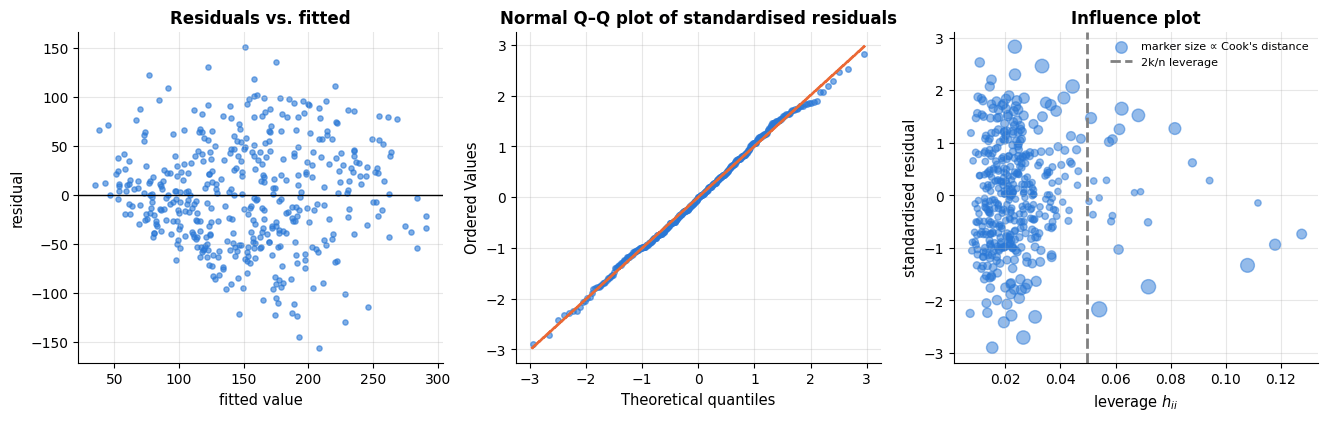

average leverage k/n = 0.025;  rows with Cook's distance > 4/n: 22


In [9]:
fitted = Xd @ theta                     # fitted values y_hat
n_rows, k_params = Xd.shape
sigma2_hat = np.sum(residuals ** 2) / (n_rows - k_params)     # noise variance estimate RSS / (n - k)
# np.einsum("ij,jk,ik->i", X, A, X) computes, for every row i, the sum over j and k of X[i, j] A[j, k] X[i, k]
leverage = np.einsum("ij,jk,ik->i", Xd, np.linalg.inv(Xd.T @ Xd), Xd)       # h_ii = x_i^T (X^T X)^{-1} x_i
std_resid = residuals / np.sqrt(sigma2_hat * (1 - leverage))   # each residual divided by its own standard deviation
cooks = std_resid ** 2 / k_params * leverage / (1 - leverage)  # Cook's distance (the formula in the markdown above)

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
axes[0].scatter(fitted, residuals, s=14, alpha=0.6)
axes[0].axhline(0, color="black", lw=1)
axes[0].set_xlabel("fitted value")
axes[0].set_ylabel("residual")
axes[0].set_title("Residuals vs. fitted")
# with plot=axes[1], probplot draws the Q-Q plot itself: the points are the first line on the axes, the fitted
# straight line the second; .set(...) then changes several of their properties at once
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].get_lines()[0].set(markersize=4, alpha=0.6, color=PALETTE[0])
axes[1].get_lines()[1].set(color=PALETTE[1])
axes[1].set_title("Normal Q–Q plot of standardised residuals")
# s (the marker area) grows with Cook's distance, so influential rows show up as big circles
axes[2].scatter(leverage, std_resid, s=20 + 4000 * cooks, alpha=0.5, label="marker size ∝ Cook's distance")
axes[2].axvline(2 * k_params / n_rows, color="gray", ls="--", label="2k/n leverage")   # twice the average leverage
axes[2].set_xlabel("leverage $h_{ii}$")
axes[2].set_ylabel("standardised residual")
axes[2].set_title("Influence plot")
axes[2].legend(loc="upper right", fontsize=8)
plt.show()
print(f"average leverage k/n = {k_params / n_rows:.3f};  rows with Cook's distance > 4/n: {(cooks > 4 / n_rows).sum()}")

The diabetes fit passes with minor remarks: the residual band is shapeless, the Q–Q plot is
close to the line with slightly light tails, and no single patient dominates the fit. To see
what *failing* diagnostics look like, here are two synthetic problems — a hidden quadratic
term and a variance that grows with the prediction — fitted with a straight line.

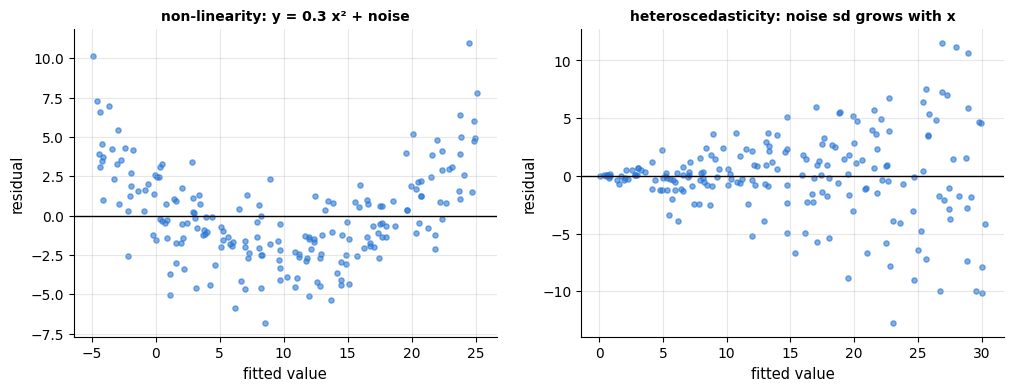

In [10]:
x_syn = rng.uniform(0, 10, 200)           # 200 x-values drawn uniformly from [0, 10)
problems = {
    "non-linearity: y = 0.3 x² + noise": 0.3 * x_syn ** 2 + rng.normal(0, 2, 200),
    # rng.normal accepts one standard deviation per point: here it grows with x (0.6 x)
    "heteroscedasticity: noise sd grows with x": 3 * x_syn + rng.normal(0, 0.6 * x_syn, 200),
}
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, (title, y_syn) in zip(axes, problems.items()):
    lin = LinearRegression().fit(x_syn[:, None], y_syn)    # x_syn[:, None]: shape (200,) -> (200, 1), a 2-D X
    # residuals (observed - predicted) against fitted values
    ax.scatter(lin.predict(x_syn[:, None]), y_syn - lin.predict(x_syn[:, None]), s=14, alpha=0.6)
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("fitted value")
    ax.set_ylabel("residual")
    ax.set_title(title, fontsize=10)
plt.show()

A curved band (left) says "add a non-linear feature" (section 6); a funnel (right) says
"transform the target, or use weighted least squares", and it also means the analytic
standard errors of section 3 are wrong even though the coefficients are still unbiased.

### 4.2 Multicollinearity and the variance inflation factor

If two features are nearly collinear, the loss surface is nearly flat along the direction
that trades one coefficient for the other, so the individual coefficients are poorly
determined even though the *predictions* are fine. The **variance inflation factor** of
feature $j$ is

$$
\text{VIF}_j = \frac{1}{1 - R_j^2},
$$

where $R_j^2$ is the $R^2$ of a regression of $x_j$ on all other features. It is exactly the
factor by which the variance of $\hat w_j$ is inflated relative to a world in which $x_j$
were uncorrelated with the rest. Values above 5–10 signal trouble.

In [11]:
def variance_inflation_factors(X):
    """Variance inflation factor of every column of X: VIF_j = 1 / (1 - R_j^2).

    R_j^2 is the R^2 of a linear regression of column j on all the other columns.
    Returns a NumPy array with one VIF per column.
    """
    X = np.asarray(X, dtype=float)
    vif = []
    for j in range(X.shape[1]):
        others = np.delete(X, j, axis=1)                  # a copy of X without column j
        r2 = LinearRegression().fit(others, X[:, j]).score(others, X[:, j])    # .score of a regressor is R^2
        vif.append(1 / (1 - r2))
    return np.array(vif)

vif = pd.Series(variance_inflation_factors(X_diab), index=feature_names)
print("variance inflation factors:")
print(vif.round(1).to_string())       # .to_string() prints the whole Series without the dtype line
print("\ncorrelation between the serum measurements:")
print(X_diab[["s1", "s2", "s3", "s4", "s5"]].corr().round(2))      # pairwise Pearson correlations

variance inflation factors:
age     1.2
sex     1.3
bmi     1.5
bp      1.5
s1     59.2
s2     39.2
s3     15.4
s4      8.9
s5     10.1
s6      1.5

correlation between the serum measurements:
      s1    s2    s3    s4    s5
s1  1.00  0.90  0.05  0.54  0.52
s2  0.90  1.00 -0.20  0.66  0.32
s3  0.05 -0.20  1.00 -0.74 -0.40
s4  0.54  0.66 -0.74  1.00  0.62
s5  0.52  0.32 -0.40  0.62  1.00


`s1` (total cholesterol) and `s2` (LDL) are correlated at 0.90 and have VIFs of 59 and 39:
their standard errors are inflated by factors of $\sqrt{59} \approx 7.7$ and
$\sqrt{39} \approx 6.2$, which is why their confidence intervals in section 3.2 were so
wide and of opposite signs. The remedies are to drop or combine redundant features, to
collect more data — or to regularise, which is where section 7 begins.

## 5. Regression metrics and robust regression

### 5.1 Which number to report

| Metric | Formula | Properties | Use when |
|---|---|---|---|
| MSE | $\frac{1}{n}\sum (y_i - \hat y_i)^2$ | what least squares minimises; units of $y^2$; dominated by large errors | optimisation, comparing models on one dataset |
| RMSE | $\sqrt{\text{MSE}}$ | same units as $y$; the standard deviation of the errors if unbiased | the default report |
| MAE | $\frac{1}{n}\sum \lvert y_i - \hat y_i \rvert$ | robust to outliers; the optimal constant prediction is the median | heavy-tailed errors; "typical" error |
| MAPE | $\frac{100}{n}\sum \left\lvert \frac{y_i - \hat y_i}{y_i} \right\rvert$ | scale-free; undefined at $y = 0$, explodes near it, penalises over-prediction more than under-prediction | business reporting with strictly positive targets |
| $R^2$ | $1 - \frac{\sum (y_i - \hat y_i)^2}{\sum (y_i - \bar y)^2}$ | fraction of variance explained *relative to predicting the mean*; can be negative on test data; the `score` of every regressor | comparing across targets of different scale |
| adjusted $R^2$ | $1 - (1 - R^2)\frac{n - 1}{n - d - 1}$ | penalises the number of features; only meaningful on training data | classical model comparison on training data |

$R^2$ deserves a comment. On the training data it can only increase when a feature is added
(hence the adjusted version), and it is bounded by 1. On *test* data it is simply
$1 - \text{MSE}_\text{model} / \text{MSE}_\text{mean baseline}$: negative values mean the
model is worse than predicting the training mean — a `DummyRegressor` baseline, which every
regression experiment should include (notebook 5, section 5).

In [12]:
from sklearn.model_selection import train_test_split
# the metrics of the table above; note that mean_absolute_percentage_error returns a fraction, not a percentage
from sklearn.metrics import mean_squared_error, root_mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.dummy import DummyRegressor        # a baseline that ignores the features

# hold out a random 25 % of the patients as a test set
Xtr, Xte, ytr, yte = train_test_split(X_diab, y_diab, test_size=0.25, random_state=RANDOM_STATE)
ols = LinearRegression().fit(Xtr, ytr)
pred = ols.predict(Xte)
err = yte - pred                        # test errors, one per patient
n_te, d_feat = Xte.shape
by_hand = {
    "MSE": np.mean(err ** 2), "RMSE": np.sqrt(np.mean(err ** 2)), "MAE": np.mean(np.abs(err)),
    "MAPE (%)": 100 * np.mean(np.abs(err / yte)),
    "R2": 1 - np.sum(err ** 2) / np.sum((yte - yte.mean()) ** 2),
}
by_hand["adjusted R2"] = 1 - (1 - by_hand["R2"]) * (n_te - 1) / (n_te - d_feat - 1)
sklearn_values = {
    "MSE": mean_squared_error(yte, pred), "RMSE": root_mean_squared_error(yte, pred), "MAE": mean_absolute_error(yte, pred),
    # scikit-learn has no adjusted R^2, hence NaN
    "MAPE (%)": 100 * mean_absolute_percentage_error(yte, pred), "R2": r2_score(yte, pred), "adjusted R2": np.nan,
}
# a dict of dicts becomes a table: the outer keys are the columns, the inner keys the rows
metrics = pd.DataFrame({"by hand": by_hand, "scikit-learn": sklearn_values}).round(3)
display(metrics)
baseline = DummyRegressor(strategy="mean").fit(Xtr, ytr)        # always predicts the training mean
print(f"mean-baseline test RMSE = {root_mean_squared_error(yte, baseline.predict(Xte)):.2f}, R2 = {r2_score(yte, baseline.predict(Xte)):.3f}")

,by hand,scikit-learn
MSE,2848.311,2848.311
RMSE,53.370,53.370
MAE,41.549,41.549
MAPE (%),37.311,37.311
R2,0.485,0.485
adjusted R2,0.433,NaN


mean-baseline test RMSE = 74.88, R2 = -0.014


A test RMSE of about 55 on a target with standard deviation 77, and $R^2 \approx 0.5$: the
linear model halves the baseline's squared error, and the rest is mostly noise (the
learning-curve exercise of notebook 5 showed that more patients would not help much).

### 5.2 Robust regression

Because the squared loss grows quadratically, a few wild points can pull the least-squares
line far from where the bulk of the data lies. Two remedies:

- **Huber regression** (Huber, 1964) replaces the square by a loss that is quadratic for
  small residuals and *linear* beyond a threshold $\epsilon$, so that outliers contribute a
  bounded gradient. `HuberRegressor` estimates the scale of the residuals jointly.
- **RANSAC** (Fischler & Bolles, 1981) fits the model on random minimal subsets, counts how
  many points are *inliers* (residual below a threshold), and keeps the consensus set with
  the most inliers. Robust to a large fraction of gross outliers; used in computer vision.

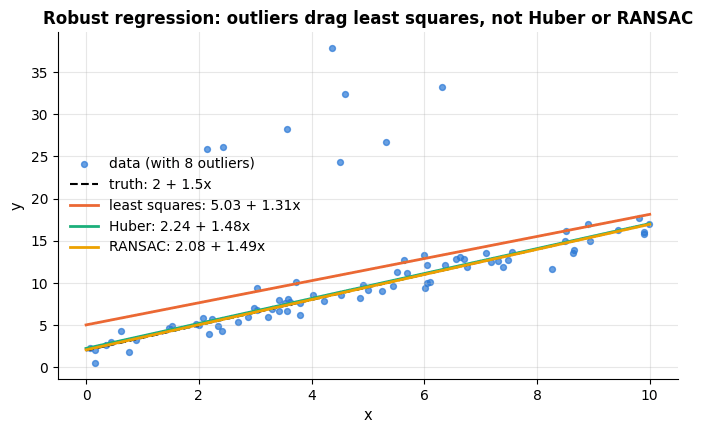

In [13]:
# HuberRegressor: squared loss for small residuals, absolute (linear) loss for large ones;
# RANSACRegressor: fits on random small subsets and keeps the model that has the most inliers
from sklearn.linear_model import HuberRegressor, RANSACRegressor

x_out = rng.uniform(0, 10, 80)
y_out = 2 + 1.5 * x_out + rng.normal(0, 1, 80)                  # true line 2 + 1.5 x plus Gaussian noise
outliers = rng.choice(80, 8, replace=False)                     # 8 distinct row positions
y_out[outliers] += rng.uniform(15, 30, 8)                       # 10 % gross outliers, all upwards

fits = {"least squares": LinearRegression(), "Huber": HuberRegressor(), "RANSAC": RANSACRegressor(random_state=RANDOM_STATE)}
grid = np.linspace(0, 10, 50)[:, None]          # 50 x positions as a column, shape (50, 1), for predict
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x_out, y_out, s=18, alpha=0.7, color=PALETTE[0], label="data (with 8 outliers)")
ax.plot(grid, 2 + 1.5 * grid, color="black", lw=1.5, ls="--", label="truth: 2 + 1.5x")
for (name, model), color in zip(fits.items(), PALETTE[1:4]):     # PALETTE[1:4]: three colours, one per model
    model.fit(x_out[:, None], y_out)
    # RANSAC wraps a LinearRegression; its final fit on the inliers is .estimator_, which has intercept_ and coef_
    est = model.estimator_ if name == "RANSAC" else model
    ax.plot(grid, model.predict(grid), color=color, lw=2, label=f"{name}: {est.intercept_:.2f} + {est.coef_[0]:.2f}x")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Robust regression: outliers drag least squares, not Huber or RANSAC")
ax.legend()
plt.show()

Least squares is pulled upwards by the eight outliers (intercept and slope both too large);
Huber and RANSAC recover the true line. Use them when you *know* the data contain gross
errors that are not part of the population you want to predict; do not use them to hide
genuine heavy tails.

## 6. Beyond straight lines: polynomial and spline features

A linear model in *transformed* features is still a linear model — the normal equations,
diagnostics and regularisation all apply — but it can fit curves. Notebook 5 used
`PolynomialFeatures` to demonstrate overfitting; here we compare polynomials with the
generally better alternative, **splines**. A polynomial of degree $p$ is global: every
coefficient affects the whole range, and high degrees oscillate wildly near the edges and
explode outside the data. A **B-spline basis** (`SplineTransformer`) instead consists of
local bumps, piecewise polynomials of degree 3 that join smoothly at *knots*; each
coefficient only affects the curve near its knot, so the fit is stable, and outside the data
range it continues as a constant (`extrapolation="constant"`) or a straight line.

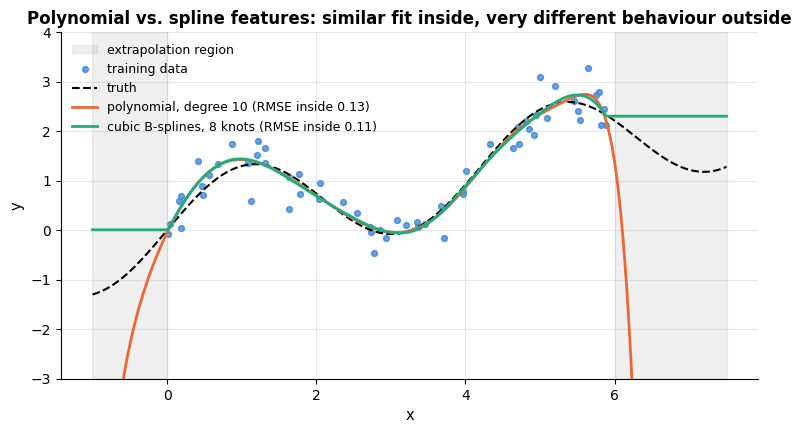

In [14]:
# SplineTransformer: a B-spline basis (local cubic bumps between knots), one output column per basis function
from sklearn.preprocessing import PolynomialFeatures, SplineTransformer
from sklearn.pipeline import make_pipeline       # a Pipeline whose steps are named automatically after their classes
from sklearn.linear_model import Ridge           # least squares plus an L2 penalty (section 7.1)

def truth(x):
    """The true curve of this toy problem: sin(1.5 x) + 0.3 x."""
    return np.sin(1.5 * x) + 0.3 * x

x_curve = rng.uniform(0, 6, 60)
y_curve = truth(x_curve) + rng.normal(0, 0.3, 60)
grid = np.linspace(-1, 7.5, 300)        # reaches beyond the data range [0, 6] on both sides
curve_models = {
    # PolynomialFeatures(10): all powers x^0 ... x^10 (scaling first keeps the high powers numerically manageable)
    "polynomial, degree 10": make_pipeline(StandardScaler(), PolynomialFeatures(10), LinearRegression()),
    # 8 evenly spaced knots, cubic pieces (degree=3); beyond the data range the fitted curve stays constant
    "cubic B-splines, 8 knots": make_pipeline(SplineTransformer(n_knots=8, degree=3), LinearRegression()),
}
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.axvspan(-1, 0, color="gray", alpha=0.12)      # axvspan shades a vertical band: the regions without data
ax.axvspan(6, 7.5, color="gray", alpha=0.12, label="extrapolation region")
ax.scatter(x_curve, y_curve, s=18, color=PALETTE[0], alpha=0.7, label="training data")
ax.plot(grid, truth(grid), color="black", lw=1.5, ls="--", label="truth")
inside = (grid >= 0) & (grid <= 6)       # True for the grid points inside the training range
for (name, model), color in zip(curve_models.items(), PALETTE[1:3]):
    pred = model.fit(x_curve[:, None], y_curve).predict(grid[:, None])      # fit and predict in one chain
    rmse_in = np.sqrt(np.mean((pred[inside] - truth(grid[inside])) ** 2))   # error against the truth, inside only
    ax.plot(grid, pred, color=color, lw=2, label=f"{name} (RMSE inside {rmse_in:.2f})")
ax.set_ylim(-3, 4)        # fixed y-range: the polynomial shoots far off the chart outside the data
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title("Polynomial vs. spline features: similar fit inside, very different behaviour outside")
ax.legend(loc="upper left", fontsize=9)
plt.show()

Inside the data both fit well; outside, the degree-10 polynomial shoots off the chart (its
value at $x = 7.5$ is in the hundreds) while the spline stays put. **Interaction terms** —
products $x_j x_k$ — are the other standard extension (`PolynomialFeatures(degree=2,
interaction_only=True)`); notebook 4 showed the product `tenure × monthly charges` turning a
mediocre fit into a near-perfect one.

Every basis expansion moves the model along the bias–variance trade-off of notebook 5: more
knots or a higher degree reduce bias and increase variance. Rather than choosing the number
of knots by cross-validation, the modern approach is to use a generous basis and control
variance with regularisation — the subject of the next section.

## 7. Regularisation

### 7.1 Ridge regression

Least squares can have high variance: with many features, correlated features, or few
samples, the coefficients swing wildly from one sample to the next (section 4.2, notebook 5
section 3). **Ridge regression** (Hoerl & Kennard, 1970) adds a penalty on the size of the
coefficients:

$$
\hat{\mathbf{w}}_\text{ridge} \;=\; \arg\min_{\mathbf{w}} \;\|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2 + \lambda \|\mathbf{w}\|_2^2 ,
\qquad \lambda \ge 0 .
$$

(The intercept is not penalised; scikit-learn centres $\mathbf{y}$ and the columns of
$\mathbf{X}$ to handle it, and calls $\lambda$ `alpha`.) Setting the gradient to zero gives a
closed form that differs from the normal equations by one term:

$$
2\mathbf{X}^\top(\mathbf{X}\mathbf{w} - \mathbf{y}) + 2\lambda\mathbf{w} = \mathbf{0}
\quad\Longrightarrow\quad
\hat{\mathbf{w}}_\text{ridge} = (\mathbf{X}^\top\mathbf{X} + \lambda\mathbf{I})^{-1}\mathbf{X}^\top\mathbf{y} .
$$

Adding $\lambda\mathbf{I}$ makes the matrix invertible even when $\mathbf{X}^\top\mathbf{X}$
is singular (collinear features, $d > n$) — this was Hoerl and Kennard's original
motivation, and it is exactly the cure for the flat directions of section 4.2. The SVD
$\mathbf{X} = \mathbf{U}\mathbf{S}\mathbf{V}^\top$ shows what the penalty does geometrically:
the fitted values are

$$
\hat{\mathbf{y}}_\text{ridge} = \sum_{j=1}^{d} \mathbf{u}_j \,\frac{s_j^2}{s_j^2 + \lambda}\, \mathbf{u}_j^\top \mathbf{y},
$$

a *shrunken* projection: the component of $\mathbf{y}$ along the $j$-th principal direction
of the data is multiplied by $s_j^2 / (s_j^2 + \lambda)$, close to 1 for directions with
large variance $s_j^2$ and close to 0 for low-variance directions — precisely the directions
in which least squares is unstable. Ridge trades a little bias for a large reduction in
variance. Because the penalty is on the coefficients' *size*, the features must be on a
common scale: **standardise before regularising**, always.

In [15]:
yc = yd - yd.mean()                                   # centred target; Xs is already standardised
lam = 10.0                                            # the penalty strength lambda (called alpha in scikit-learn)
# closed form: solve (X^T X + lambda I) w = X^T y; np.eye(d) is the d x d identity matrix
w_closed = np.linalg.solve(Xs.T @ Xs + lam * np.eye(Xs.shape[1]), Xs.T @ yc)
U, s, Vt = np.linalg.svd(Xs, full_matrices=False)    # thin SVD Xs = U diag(s) Vt: U (442, 10), s (10,), Vt (10, 10)
# SVD form w = V diag(s_j / (s_j^2 + lambda)) U^T y: the element-wise product applies one factor per direction
w_svd = Vt.T @ (s / (s ** 2 + lam) * (U.T @ yc))
w_sklearn = Ridge(alpha=lam).fit(Xs, yd).coef_       # Ridge fits the unpenalised intercept itself, so it gets yd
print(f"max |closed form - Ridge| = {np.abs(w_closed - w_sklearn).max():.1e};  max |SVD form - Ridge| = {np.abs(w_svd - w_sklearn).max():.1e}")
print("singular values s_j:      ", s.round(1))       # sorted from largest to smallest
print("shrinkage s_j^2/(s_j^2+10):", (s ** 2 / (s ** 2 + lam)).round(3))

max |closed form - Ridge| = 1.6e-13;  max |SVD form - Ridge| = 2.1e-13
singular values s_j:       [42.2 25.7 23.1 20.6 17.1 16.3 15.4 13.8  5.9  1.9]
shrinkage s_j^2/(s_j^2+10): [0.994 0.985 0.982 0.977 0.967 0.964 0.96  0.95  0.776 0.275]


The shrinkage factors tell the story: the eight strong directions are barely touched, while
the two weakest (the collinear serum directions, singular values 5.9 and 1.9) are shrunk to
78 % and 27 %.

### 7.2 Lasso: the $\ell_1$ penalty and sparsity

The **lasso** (Tibshirani, 1996) penalises the $\ell_1$ norm instead. scikit-learn's
parametrisation is

$$
\hat{\mathbf{w}}_\text{lasso} \;=\; \arg\min_{\mathbf{w}} \;\frac{1}{2n}\|\mathbf{y} - \mathbf{X}\mathbf{w}\|_2^2 + \alpha \|\mathbf{w}\|_1 ,
$$

(note the $1/2n$, which makes `alpha` comparable across dataset sizes; ridge's `alpha` has
no such factor). The absolute value has a kink at zero, and that kink is the whole point: the
lasso sets some coefficients *exactly* to zero, performing feature selection as a by-product
of fitting (notebook 4, section 7.3). There is no closed form, but **coordinate descent**
(Friedman, Hastie & Tibshirani, 2010) is simple and fast. Holding all coefficients but
$w_j$ fixed, the objective is a one-dimensional quadratic plus $\alpha |w_j|$, whose minimiser
is the **soft-thresholding** of the least-squares update:

$$
w_j \;\leftarrow\; \frac{S\!\left(\tfrac{1}{n}\mathbf{x}_j^\top \mathbf{r}_{(j)},\; \alpha\right)}{\tfrac{1}{n}\mathbf{x}_j^\top\mathbf{x}_j},
\qquad
S(\rho, \alpha) = \operatorname{sign}(\rho)\,\max(|\rho| - \alpha, 0),
$$

where $\mathbf{r}_{(j)} = \mathbf{y} - \sum_{k \ne j} \mathbf{x}_k w_k$ is the residual
without feature $j$'s contribution. Whenever the correlation $\frac{1}{n}\mathbf{x}_j^\top\mathbf{r}_{(j)}$
of a feature with the current residual is below $\alpha$ in absolute value, its coefficient
is set to zero. Cycling through the coordinates until nothing changes converges to the
global minimum, because the objective is convex.

In [16]:
from sklearn.linear_model import Lasso, lasso_path     # lasso_path fits the lasso for a whole sequence of alphas

def soft_threshold(rho, alpha):
    """Soft thresholding S(rho, alpha) = sign(rho) * max(|rho| - alpha, 0): move rho towards 0 by alpha, stopping at 0."""
    return np.sign(rho) * np.maximum(np.abs(rho) - alpha, 0.0)

def lasso_coordinate_descent(X, y, alpha, max_iter=1000, tol=1e-6):
    """Lasso in scikit-learn's parametrisation, for centred y and standardised X.

    Cycles through the coefficients, setting each one to its soft-thresholded least-squares update, until no
    coefficient changes by more than tol in a full sweep (or after max_iter sweeps). Returns w, of length d.
    """
    n, d = X.shape
    w = np.zeros(d)
    col_norm2 = (X ** 2).sum(axis=0) / n      # (1/n) x_j^T x_j for every column (1 for standardised columns)
    for _ in range(max_iter):
        w_old = w.copy()                       # a real copy, because w is changed in place below
        for j in range(d):
            partial_residual = y - X @ w + X[:, j] * w[j]           # residual without feature j
            rho = X[:, j] @ partial_residual / n           # correlation of feature j with that residual
            w[j] = soft_threshold(rho, alpha) / col_norm2[j]
        if np.abs(w - w_old).max() < tol:      # converged: the largest change in this sweep is tiny
            break
    return w

for alpha in [0.5, 2.0, 5.0]:
    w_cd = lasso_coordinate_descent(Xs, yc, alpha)
    w_sk = Lasso(alpha=alpha).fit(Xs, yd).coef_
    print(f"alpha = {alpha:4.1f}: max |coordinate descent - Lasso| = {np.abs(w_cd - w_sk).max():.1e};  "
          f"non-zero coefficients: {(np.abs(w_sk) > 1e-8).sum()} of {Xs.shape[1]}")

alpha =  0.5: max |coordinate descent - Lasso| = 1.8e-02;  non-zero coefficients: 8 of 10
alpha =  2.0: max |coordinate descent - Lasso| = 1.2e-03;  non-zero coefficients: 7 of 10
alpha =  5.0: max |coordinate descent - Lasso| = 2.1e-03;  non-zero coefficients: 5 of 10


The two regularisation paths — every coefficient as a function of the penalty — make the
difference between the penalties visible. Ridge shrinks all coefficients smoothly towards
zero and never reaches it; the lasso path is piecewise linear (Efron et al., 2004), and
coefficients hit zero one after another.

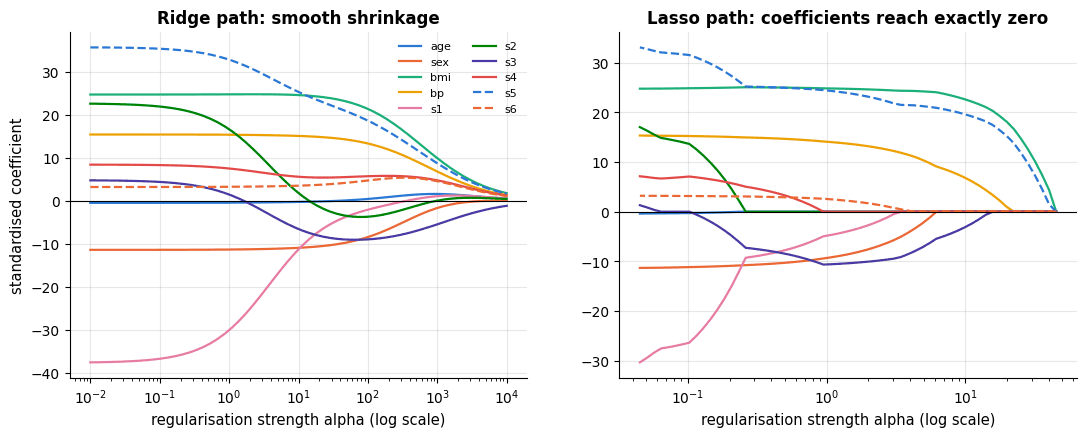

In [17]:
ridge_alphas = np.logspace(-2, 4, 60)      # 60 penalties from 10^-2 to 10^4, evenly spaced on a log scale
ridge_coefs = np.array([Ridge(alpha=a).fit(Xs, yd).coef_ for a in ridge_alphas])    # shape (60, 10): one row per alpha
# lasso_path returns (alphas, coefficients of shape (n_features, n_alphas), dual gaps); eps = smallest / largest alpha
lasso_alphas, lasso_coefs, _ = lasso_path(Xs, yc, n_alphas=60, eps=1e-3)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for j, name in enumerate(feature_names):
    # PALETTE has 8 colours: j % 8 cycles through them, and the 9th and 10th features are dashed to tell them apart;
    # ridge_coefs[:, j] is column j (features are columns there), lasso_coefs[j] is row j (features are rows there)
    axes[0].plot(ridge_alphas, ridge_coefs[:, j], lw=1.6, label=name, color=PALETTE[j % 8], ls="-" if j < 8 else "--")
    axes[1].plot(lasso_alphas, lasso_coefs[j], lw=1.6, label=name, color=PALETTE[j % 8], ls="-" if j < 8 else "--")
for ax, title in zip(axes, ["Ridge path: smooth shrinkage", "Lasso path: coefficients reach exactly zero"]):
    ax.set_xscale("log")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("regularisation strength alpha (log scale)")
    ax.set_title(title)
axes[0].set_ylabel("standardised coefficient")
axes[0].legend(fontsize=8, ncol=2)
plt.show()

The correlated pair `s1`/`s2` is instructive: for small penalties they carry large
coefficients of opposite sign that nearly cancel (the flat direction); ridge pulls both
towards zero together, while the lasso keeps one and drops the other.

### 7.3 Why the $\ell_1$ ball gives sparsity, and elastic net

Both penalised problems can be written as *constrained* least squares: minimise the RSS
subject to $\|\mathbf{w}\|_2 \le t$ (ridge) or $\|\mathbf{w}\|_1 \le t$ (lasso). In two
dimensions the RSS contours are ellipses centred at the least-squares solution, and the
solution is the first point where an ellipse touches the constraint region. The $\ell_2$
region is a disc: the touching point is almost never on an axis. The $\ell_1$ region is a
diamond with corners *on* the axes, and an expanding ellipse typically hits a corner — where
one coefficient is exactly zero.

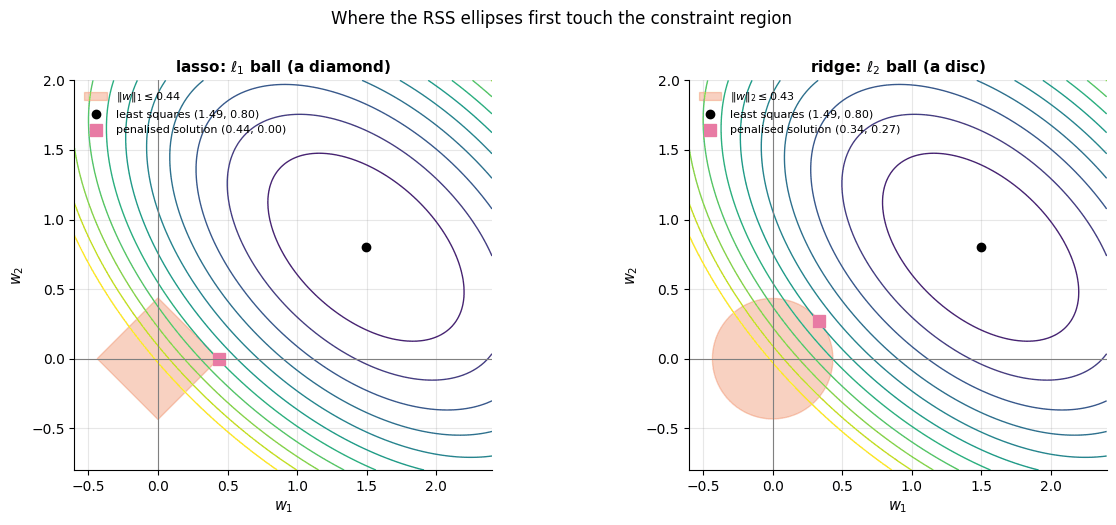

lasso penalty at the corner: alpha = 1.036  ->  w = (0.437, 0.000)
ridge of the same coefficient length:              w = (0.336, 0.273)


In [18]:
# multiplying independent normal columns by a 2 x 2 matrix mixes them, which makes the two columns correlated
X2 = rng.normal(size=(60, 2)) @ np.array([[1.0, 0.6], [0.0, 0.8]])     # two correlated features
y2 = X2 @ np.array([1.6, 0.9]) + rng.normal(0, 0.6, 60)       # true coefficients (1.6, 0.9)
X2, y2 = X2 - X2.mean(0), y2 - y2.mean()                       # centre both, so no intercept is needed
w_ols2 = np.linalg.lstsq(X2, y2, rcond=None)[0]               # [0]: the solution from lstsq's returned tuple
# a 200 x 200 grid of coefficient pairs (w1, w2); W1 and W2 hold the two coordinates of every grid point
W1, W2 = np.meshgrid(np.linspace(-0.6, 2.4, 200), np.linspace(-0.8, 2.0, 200))
# mean squared error at every grid point at once: y2[:, None, None] has shape (60, 1, 1) and W1 is (200, 200), so the
# expression broadcasts to (60, 200, 200); .mean(axis=0) averages over the 60 samples -> (200, 200)
rss = ((y2[:, None, None] - X2[:, 0, None, None] * W1 - X2[:, 1, None, None] * W2) ** 2).mean(axis=0)

# take the weakest penalty that already drives w_2 exactly to zero — the corner of the diamond
path_alphas, path_coefs, _ = lasso_path(X2, y2, n_alphas=80, eps=1e-3)
alpha_corner = path_alphas[np.abs(path_coefs[1]) < 1e-12].min()     # smallest alpha on the path at which w_2 is 0
w_lasso2 = Lasso(alpha=alpha_corner, fit_intercept=False).fit(X2, y2).coef_     # data are centred: no intercept
# a ridge penalty that shrinks the coefficient vector to the same length, for a fair comparison
# (min(candidates, key=f) returns the candidate with the smallest f: the ridge fit whose norm is closest to the lasso's)
w_ridge2 = min((Ridge(alpha=a, fit_intercept=False).fit(X2, y2).coef_ for a in np.logspace(-1, 3, 200)),
               key=lambda w: abs(np.linalg.norm(w) - np.linalg.norm(w_lasso2)))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.2))
theta_c = np.linspace(0, 2 * np.pi, 400)       # angles for drawing a circle
for ax, w_pen, name in zip(axes, [w_lasso2, w_ridge2], ["lasso: $\\ell_1$ ball (a diamond)", "ridge: $\\ell_2$ ball (a disc)"]):
    # contour lines of the error surface: 12 levels from its minimum up to minimum + 3
    ax.contour(W1, W2, rss, levels=np.linspace(rss.min(), rss.min() + 3, 12), cmap="viridis", linewidths=1)
    if name.startswith("lasso"):
        t = np.abs(w_pen).sum()          # the l1 length of the lasso solution
        # ax.fill draws a filled polygon: the diamond |w1| + |w2| <= t, with corners (t, 0), (0, t), (-t, 0), (0, -t)
        ax.fill(t * np.array([1, 0, -1, 0]), t * np.array([0, 1, 0, -1]), color=PALETTE[1], alpha=0.3, label=f"$\\|w\\|_1 \\leq {t:.2f}$")
    else:
        t = np.linalg.norm(w_pen)        # the l2 length of the ridge solution; the polygon below is a disc of radius t
        ax.fill(t * np.cos(theta_c), t * np.sin(theta_c), color=PALETTE[1], alpha=0.3, label=f"$\\|w\\|_2 \\leq {t:.2f}$")
    # *w unpacks the two coordinates into x and y; "o" and "s" draw a circle and a square marker without a line
    ax.plot(*w_ols2, "o", color="black", label=f"least squares ({w_ols2[0]:.2f}, {w_ols2[1]:.2f})")
    ax.plot(*w_pen, "s", color=PALETTE[4], ms=9, label=f"penalised solution ({w_pen[0]:.2f}, {w_pen[1]:.2f})")
    ax.axhline(0, color="gray", lw=0.8)
    ax.axvline(0, color="gray", lw=0.8)
    ax.set_xlabel("$w_1$")
    ax.set_ylabel("$w_2$")
    ax.set_title(name, fontsize=11)
    ax.set_aspect("equal")               # the same scale on both axes, so the disc looks round
    ax.legend(loc="upper left", fontsize=8)
fig.suptitle("Where the RSS ellipses first touch the constraint region", y=1.0)
plt.tight_layout()
plt.show()
print(f"lasso penalty at the corner: alpha = {alpha_corner:.3f}  ->  w = ({w_lasso2[0]:.3f}, {w_lasso2[1]:.3f})")
print(f"ridge of the same coefficient length:              w = ({w_ridge2[0]:.3f}, {w_ridge2[1]:.3f})")

The lasso solution sits at the corner $w_2 = 0$; the ridge solution is shrunk along a curve
towards the origin and keeps both coefficients. The **elastic net** (Zou & Hastie, 2005)
combines the two, $\alpha\,[\,\rho\|\mathbf{w}\|_1 + \tfrac{1 - \rho}{2}\|\mathbf{w}\|_2^2\,]$
with mixing parameter $\rho$ = `l1_ratio`: it keeps the sparsity of the lasso but behaves
better with groups of correlated features, which the lasso tends to pick from arbitrarily
and which the $\ell_2$ term encourages to enter together.

> **Going deeper — the Bayesian view.** Notebook 2 showed that maximum a posteriori (MAP)
> estimation adds $-\log p(\mathbf{w})$ to the negative log-likelihood. A Gaussian prior
> $\mathbf{w} \sim \mathcal{N}(\mathbf{0}, \tau^2\mathbf{I})$ gives $-\log p(\mathbf{w}) \propto \|\mathbf{w}\|_2^2$
> — ridge regression is the MAP estimate under a Gaussian prior, with $\lambda = \sigma^2/\tau^2$;
> a Laplace prior $p(w_j) \propto e^{-|w_j|/b}$ gives the lasso. The prior encodes the belief
> that coefficients are small (Gaussian) or that most are exactly zero (Laplace); Murphy
> (2022, chapter 11) develops this fully.

### 7.4 Choosing the penalty: cross-validation, and which penalty when

$\lambda$ is a hyper-parameter and is chosen by cross-validation (notebook 5): `RidgeCV`
(with an efficient leave-one-out shortcut), `LassoCV` and `ElasticNetCV` (which fit the whole
path and pick the best $\alpha$ by $k$-fold CV) do this in one call. On the diabetes data
regularisation barely changes the error — $n = 442$ is comfortable for ten features — but
the lasso reaches the same error with fewer features.

In [19]:
# RidgeCV / LassoCV / ElasticNetCV choose alpha by cross-validation inside .fit and store the choice in .alpha_
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import KFold, cross_val_score

kf = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)     # 5 folds of shuffled rows, reproducible
cv_models = {
    "least squares": LinearRegression(),
    "RidgeCV": RidgeCV(alphas=np.logspace(-3, 3, 40)),        # no cv given: efficient leave-one-out over 40 alphas
    "LassoCV": LassoCV(cv=kf, random_state=RANDOM_STATE),    # its own grid of alphas along the lasso path, 5-fold CV
    "ElasticNetCV (l1_ratio 0.5)": ElasticNetCV(l1_ratio=0.5, cv=kf, random_state=RANDOM_STATE),
}
for name, model in cv_models.items():
    pipe = make_pipeline(StandardScaler(), model)      # the scaler is refitted inside every fold
    # scikit-learn scorers follow "higher is better", so errors come back negated; the leading minus undoes that
    rmse = -cross_val_score(pipe, X_diab, y_diab, cv=kf, scoring="neg_root_mean_squared_error")
    pipe.fit(X_diab, y_diab)                  # refit on all rows to inspect the chosen alpha and the coefficients
    est = pipe[-1]                            # pipe[-1] is the last step: the regression model
    # only the *CV models have alpha_; :.3g prints 3 significant digits
    chosen = f"alpha = {est.alpha_:.3g}" if hasattr(est, "alpha_") else ""
    n_nonzero = int((np.abs(est.coef_) > 1e-8).sum())      # coefficients that are not (numerically) zero
    print(f"{name:28s} CV RMSE = {rmse.mean():.2f} ± {rmse.std():.2f}   {chosen:14s}  non-zero coefficients: {n_nonzero}")

least squares                CV RMSE = 54.85 ± 2.64                   non-zero coefficients: 10
RidgeCV                      CV RMSE = 54.90 ± 2.53   alpha = 1.7     non-zero coefficients: 10
LassoCV                      CV RMSE = 54.97 ± 2.44   alpha = 0.973   non-zero coefficients: 7
ElasticNetCV (l1_ratio 0.5)  CV RMSE = 54.84 ± 2.49   alpha = 0.119   non-zero coefficients: 10


When *does* regularisation matter, and which penalty? A controlled experiment answers both:
40 correlated features, only 100 training rows, and two truths — a **sparse** one (5
non-zero coefficients) and a **dense** one (all 40 small and non-zero). We also trace the
ridge test error as a function of $\lambda$ to see the bias–variance trade-off directly.

truth,dense truth (40 small effects),sparse truth (5 of 40 non-zero)
model,,
ElasticNetCV (l1_ratio 0.5),2.501,2.425
LassoCV,2.765,2.312
RidgeCV,2.366,2.480
least squares,2.669,2.487


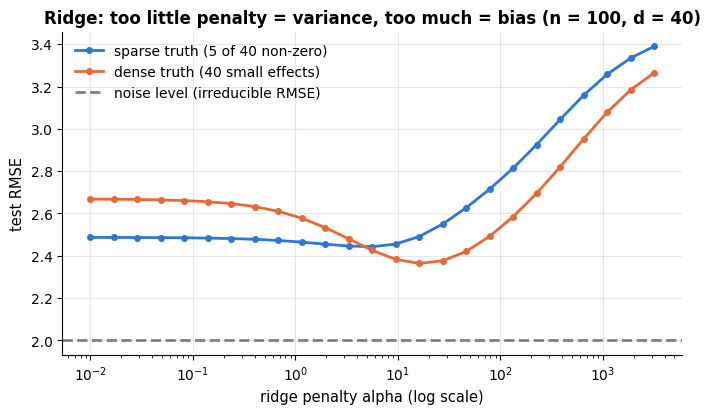

In [20]:
def make_correlated_regression(n, w_true, rho=0.7, noise=2.0, rng=rng):
    """Simulate a linear regression problem with correlated Gaussian features.

    n        number of rows
    w_true   true coefficient vector; its length d sets the number of features
    rho      features j and k have correlation rho ** |j - k| (neighbouring features are the most correlated)
    noise    standard deviation of the Gaussian noise added to y
    rng      random generator; the default is the notebook's seeded rng (bound when the function is defined)
    Returns X of shape (n, d) and y = X @ w_true + noise of shape (n,).
    """
    d = len(w_true)
    # np.subtract.outer(a, b)[j, k] = a[j] - b[k], so cov[j, k] = rho ** |j - k|
    cov = rho ** np.abs(np.subtract.outer(np.arange(d), np.arange(d)))   # AR(1) correlation between features
    # Cholesky factor L with L @ L.T = cov; independent normal rows times L.T have exactly that covariance
    X = rng.normal(size=(n, d)) @ np.linalg.cholesky(cov).T
    return X, X @ w_true + rng.normal(0, noise, n)

d_syn = 40
# sparse truth: np.r_[...] joins five non-zero coefficients and 35 zeros; dense truth: 40 small random coefficients
truths = {"sparse truth (5 of 40 non-zero)": np.r_[[3, -2, 1.5, 1, -1], np.zeros(d_syn - 5)],
          "dense truth (40 small effects)": rng.normal(0, 0.5, d_syn)}
rows = []
ridge_curves = {}
lambdas = np.logspace(-2, 3.5, 25)
for truth_name, w_true in truths.items():
    X_train_syn, y_train_syn = make_correlated_regression(100, w_true)     # only 100 training rows for 40 features
    X_test_syn, y_test_syn = make_correlated_regression(3000, w_true)      # a large test set from the same distribution
    for name, model in cv_models.items():
        pipe = make_pipeline(StandardScaler(), model).fit(X_train_syn, y_train_syn)
        rows.append({"truth": truth_name, "model": name, "test RMSE": root_mean_squared_error(y_test_syn, pipe.predict(X_test_syn))})
    # test RMSE of a plain Ridge for each of the 25 penalties
    ridge_curves[truth_name] = [root_mean_squared_error(y_test_syn, make_pipeline(StandardScaler(), Ridge(alpha=a)).fit(X_train_syn, y_train_syn).predict(X_test_syn))
                                for a in lambdas]
# .pivot reshapes the long table (one row per truth/model pair) into a grid: models as rows, truths as columns
display(pd.DataFrame(rows).pivot(index="model", columns="truth", values="test RMSE").round(3))

fig, ax = plt.subplots(figsize=(8, 4.2))
for (truth_name, curve), color in zip(ridge_curves.items(), PALETTE):
    ax.plot(lambdas, curve, marker="o", ms=4, color=color, label=truth_name)
ax.axhline(2.0, color="gray", ls="--", label="noise level (irreducible RMSE)")     # the noise sd used above
ax.set_xscale("log")
ax.set_xlabel("ridge penalty alpha (log scale)")
ax.set_ylabel("test RMSE")
ax.set_title("Ridge: too little penalty = variance, too much = bias (n = 100, d = 40)")
ax.legend()
plt.show()

With four times fewer rows per feature than the diabetes data, least squares is clearly
worse than every regularised model. The lasso wins when the truth is sparse (it recovers the
support), ridge wins when the truth is dense (shrinking everything a little is exactly
right), and the elastic net is a safe compromise. The ridge curve is the U-shape of
notebook 5, section 2, drawn against $\lambda$ instead of model complexity: $\lambda \to 0$
is least squares (high variance), $\lambda \to \infty$ predicts the mean (high bias). There
is no free lunch among penalties either — which is why `ElasticNetCV` tunes `l1_ratio` too.

> **Practical guidance.** Standardise. Start with ridge (`RidgeCV`) as the default linear
> model; use the lasso or elastic net when you expect few relevant features or want a
> compact, interpretable model; tune $\alpha$ on a log grid by CV and apply the
> one-standard-error rule. Regularisation also stabilises the ill-conditioned solves of
> section 2 — `Ridge` with a tiny `alpha` is a perfectly good replacement for
> `LinearRegression` on collinear data.

## 8. Generalised linear models: Poisson regression

Linear regression assumes a Gaussian target that can take any real value. Many targets
cannot: counts (support tickets, claims, visits) are non-negative integers whose variance
grows with their mean, and binary outcomes are 0/1. **Generalised linear models** (Nelder &
Wedderburn, 1972) keep the linear predictor $\eta = \mathbf{w}^\top\mathbf{x} + b$ but
connect it to the target's mean through a **link function** $g$ and choose a likelihood
from the exponential family:

| Target | Distribution | Link $g(\mu) = \eta$ | Mean $\mu = g^{-1}(\eta)$ | scikit-learn |
|---|---|---|---|---|
| real-valued | Gaussian | identity | $\eta$ | `LinearRegression`, `Ridge` |
| count | Poisson | $\log$ | $e^{\eta}$ | `PoissonRegressor` |
| positive, skewed | Gamma | $\log$ | $e^{\eta}$ | `GammaRegressor` |
| binary | Bernoulli | logit $\log\frac{\mu}{1-\mu}$ | $\sigma(\eta)$ | `LogisticRegression` (notebook 7) |

Poisson regression models $y \sim \text{Poisson}(\mu)$ with $\log\mu = \mathbf{w}^\top\mathbf{x} + b$:
predictions are always positive, and each coefficient acts *multiplicatively* — $e^{w_j}$ is
the factor by which the expected count changes per unit of $x_j$. Fitting maximises the
Poisson log-likelihood, equivalently minimises the **Poisson deviance**
$2\sum_i \big[y_i \log\frac{y_i}{\hat\mu_i} - (y_i - \hat\mu_i)\big]$, which plays the role
of the squared error. Let us compare a linear and a Poisson fit on simulated counts.

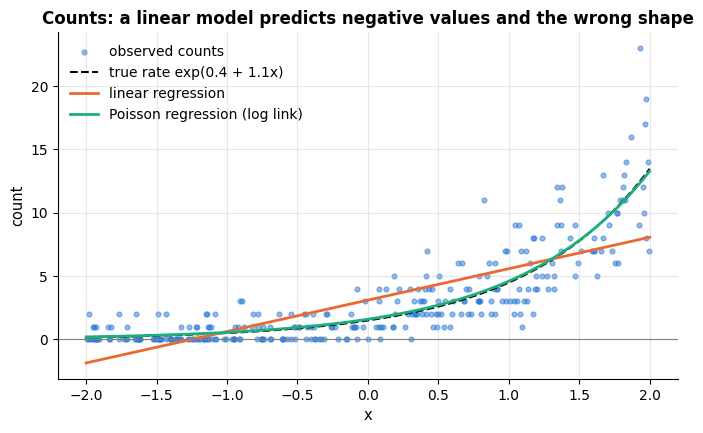

linear   test RMSE = 2.272   mean Poisson deviance = 2.510   negative predictions: 18.2%
Poisson  test RMSE = 1.726   mean Poisson deviance = 1.019   negative predictions: 0.0%
Poisson coefficients: intercept 0.462, slope 1.062  (truth 0.4 and 1.1)


In [21]:
from sklearn.linear_model import PoissonRegressor      # a GLM with a Poisson likelihood and a log link
from sklearn.metrics import mean_poisson_deviance       # the Poisson counterpart of the MSE (needs predictions > 0)

x_cnt = rng.uniform(-2, 2, 300)
# rng.poisson(lam) draws one Poisson count for each rate in lam
y_cnt = rng.poisson(np.exp(0.4 + 1.1 * x_cnt))                     # true rate: exp(0.4 + 1.1 x)
x_cnt_test = rng.uniform(-2, 2, 2000)
y_cnt_test = rng.poisson(np.exp(0.4 + 1.1 * x_cnt_test))

lin_cnt = LinearRegression().fit(x_cnt[:, None], y_cnt)
pois_cnt = PoissonRegressor(alpha=0.0).fit(x_cnt[:, None], y_cnt)    # alpha=0: no L2 penalty (the default is 1.0)
grid = np.linspace(-2, 2, 200)[:, None]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.scatter(x_cnt, y_cnt, s=12, alpha=0.5, color=PALETTE[0], label="observed counts")
ax.plot(grid, np.exp(0.4 + 1.1 * grid), color="black", ls="--", lw=1.5, label="true rate exp(0.4 + 1.1x)")
ax.plot(grid, lin_cnt.predict(grid), color=PALETTE[1], lw=2, label="linear regression")
ax.plot(grid, pois_cnt.predict(grid), color=PALETTE[2], lw=2, label="Poisson regression (log link)")
ax.axhline(0, color="gray", lw=0.8)
ax.set_xlabel("x")
ax.set_ylabel("count")
ax.set_title("Counts: a linear model predicts negative values and the wrong shape")
ax.legend()
plt.show()
for name, model in [("linear", lin_cnt), ("Poisson", pois_cnt)]:
    pred = model.predict(x_cnt_test[:, None])
    # the deviance is undefined for predictions <= 0, so np.clip(pred, 1e-6, None) raises them to 1e-6
    # (None = no upper bound); (pred < 0).mean() is the share of negative predictions
    print(f"{name:8s} test RMSE = {root_mean_squared_error(y_cnt_test, pred):.3f}   "
          f"mean Poisson deviance = {mean_poisson_deviance(y_cnt_test, np.clip(pred, 1e-6, None)):.3f}   "
          f"negative predictions: {(pred < 0).mean():.1%}")
print(f"Poisson coefficients: intercept {pois_cnt.intercept_:.3f}, slope {pois_cnt.coef_[0]:.3f}  (truth 0.4 and 1.1)")

The Poisson model recovers the generating coefficients and never predicts a negative count;
the linear model is wrong in shape and in sign at the low end. Logistic regression, the
subject of notebook 7, is the same construction with the logit link and a Bernoulli
likelihood — and everything in this notebook about solvers, scaling, coefficients,
regularisation and cross-validation carries over to it.

## 9. Strengths, weaknesses and when to use it

Every model in this notebook searches the *same* hypothesis space — functions that are
linear in the features you hand it — and they differ only in what they add to the squared
loss. That single sentence explains most of their behaviour: they share the same
assumptions, the same interpretability and the same failure modes, and the penalty decides
only where each one sits on the bias–variance line of notebook 5. The four tables below
summarise the judgement; the three experiments after them *demonstrate* the failures rather
than asserting them.

### 9.1 The four estimators at a glance

**Ordinary least squares** (`LinearRegression`)

| | |
|---|---|
| **Assumptions / inductive bias** | the conditional mean $\mathbb{E}[y \mid \mathbf{x}]$ is linear in the given features; errors independent, of constant variance, with no gross outliers; for *inference* also Gaussian. No preference among coefficient vectors — the fit is whatever the data say. |
| **Strengths** | exact closed-form solution in one pass, no hyper-parameter; unbiased under the assumptions; coefficients are directly interpretable in the units of the data; standard errors, $t$-tests and confidence intervals come for free; a strong baseline whenever $n \gg d$. |
| **Weaknesses / failure modes** | cannot represent curvature or interactions unless you build them as features (9.2); coefficients explode and become uninterpretable under collinearity (9.3); high variance when $d$ approaches $n$, and undefined when $d > n$; the squared loss is dominated by outliers (section 5.2); extrapolates linearly forever. |
| **Data it suits** | $n \gtrsim 10d$, numeric or one-hot features, no exact linear dependency, roughly symmetric noise. Scaling is irrelevant to the fit (only to gradient descent); missing values must be imputed first. |
| **Complexity** | training $O(nd^2)$ via QR/SVD ($O(nd)$ per step for gradient descent), prediction $O(d)$, memory $O(nd)$. |
| **Interpretability** | full: each $w_j$ is the change in $\hat y$ per unit of $x_j$ holding the others fixed, with an honest standard error. |
| **Use it when / avoid it when** | Use it when $n \gg d$, the features are not redundant, and you want unbiased, testable coefficients. Avoid it when features are collinear or numerous, or when the relationship is visibly curved. |

**Ridge regression** (`Ridge`, `RidgeCV`)

| | |
|---|---|
| **Assumptions / inductive bias** | same linearity assumption, plus the belief that *all* coefficients are small and no single feature dominates — a Gaussian prior on $\mathbf{w}$. Shrinks hardest along the low-variance directions of $\mathbf{X}^\top\mathbf{X}$ (section 7.1). |
| **Strengths** | always solvable, including $d > n$ and exact collinearity; large variance reduction for a little bias; handles correlated features gracefully by splitting the weight between them; `RidgeCV` tunes $\alpha$ almost for free with a leave-one-out shortcut; keeps every feature, so nothing is silently dropped. |
| **Weaknesses / failure modes** | no sparsity — with 10 000 features you get 10 000 non-zero coefficients; the estimate is biased, so classical $p$-values no longer apply; sensitive to feature scaling (a feature in kilometres is penalised differently from the same feature in metres); still cannot bend. |
| **Data it suits** | any $n$ vs. $d$, especially $d$ close to or larger than $n$; correlated features; **standardisation mandatory**. |
| **Complexity** | training $O(nd^2 + d^3)$, or $O(n^2d + n^3)$ through the dual when $d > n$; the whole $\alpha$ path costs one SVD plus $O(d)$ per value; prediction $O(d)$. |
| **Interpretability** | good, with a caveat: coefficients are shrunken towards zero, so their magnitude understates the effect; use the bootstrap, not the classical formulas, for intervals. |
| **Use it when / avoid it when** | Use it as the **default linear model**, especially with many or correlated features. Avoid it when you need a small, explicitly selected feature set. |

**Lasso** (`Lasso`, `LassoCV`)

| | |
|---|---|
| **Assumptions / inductive bias** | linearity plus *sparsity*: the belief that most coefficients are exactly zero (a Laplace prior). The $\ell_1$ kink performs selection and shrinkage simultaneously. |
| **Strengths** | produces a compact model you can read and deploy; often the best predictor when the truth really is sparse; the whole path is cheap to compute with warm starts; automatic feature selection removes a separate selection step (and its pitfalls). |
| **Weaknesses / failure modes** | among correlated features it keeps one and zeroes the rest, and *which* one is essentially arbitrary (9.4); selects at most $n$ features when $d > n$; the selected set is unstable under resampling, so post-selection $p$-values are invalid; shrinkage biases the surviving coefficients towards zero; no closed form. |
| **Data it suits** | large $d$, few genuinely relevant features, ideally weakly correlated; **standardisation mandatory**. |
| **Complexity** | coordinate descent, $O(nd)$ per sweep; a full path of 100 $\alpha$s costs a small multiple of a single fit; prediction $O(\lVert\mathbf{w}\rVert_0)$. |
| **Interpretability** | highest of the four *if* you remember that "not selected" means "redundant given the others", not "irrelevant"; report selection frequencies over bootstrap resamples instead of a single subset. |
| **Use it when / avoid it when** | Use it when you want few features and expect most to be useless. Avoid it when features come in correlated groups you want to keep together, or when you need stable coefficients. |

**Elastic net** (`ElasticNet`, `ElasticNetCV`)

| | |
|---|---|
| **Assumptions / inductive bias** | a mixture of the two beliefs above: mostly-zero coefficients, but correlated features should enter or leave *together* (the grouping effect of Zou & Hastie, 2005). |
| **Strengths** | sparse like the lasso and stable like ridge; can select more than $n$ features when $d > n$; the safest default when you know neither how sparse nor how correlated the truth is. |
| **Weaknesses / failure modes** | two hyper-parameters instead of one, and they interact (section 10); at `l1_ratio` close to 0 it is ridge with extra cost, at 1.0 it is exactly the lasso; the double shrinkage biases coefficients slightly more than either pure penalty. |
| **Data it suits** | $d > n$ with groups of correlated features — genomics, spectra, text, sensor arrays; **standardisation mandatory**. |
| **Complexity** | as the lasso, times the size of the `l1_ratio` grid. |
| **Interpretability** | as the lasso, with more stable membership of the selected set. |
| **Use it when / avoid it when** | Use it when $d$ is large *and* features are correlated. Avoid it when a single penalty already does the job — the extra parameter costs tuning time. |

### 9.2 Failure mode 1: a straight line cannot bend

The most common way a linear model fails is also the easiest to detect: the relationship is
curved, the residuals keep the curvature, and every prediction at the ends of the range is
biased in the same direction. We generate a saturating dose–response curve — the kind of
relationship that is everywhere in biology and economics — and fit a straight line to it.

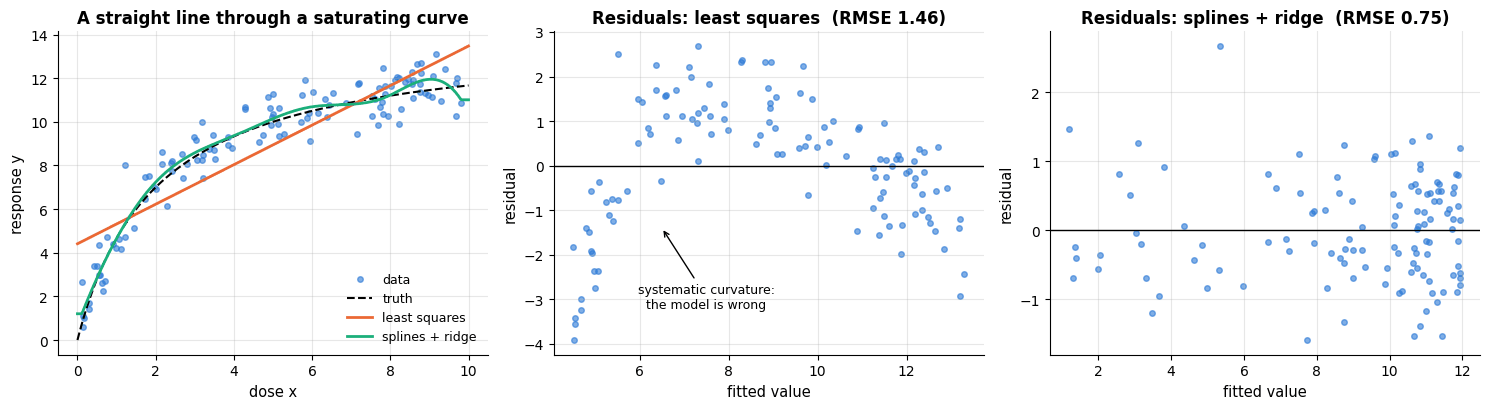

least squares R² = 0.781;  splines + ridge R² = 0.942


In [22]:
x_dose = rng.uniform(0, 10, 120)
y_dose = 14 * x_dose / (2 + x_dose) + rng.normal(0, 0.8, 120)        # saturating truth
dose_grid = np.linspace(0, 10, 300)[:, None]

ols_dose = LinearRegression().fit(x_dose[:, None], y_dose)
# a cubic spline basis with 6 knots, fitted with a very small ridge penalty
spline_dose = make_pipeline(SplineTransformer(n_knots=6, degree=3), Ridge(alpha=1e-3)).fit(x_dose[:, None], y_dose)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
axes[0].scatter(x_dose, y_dose, s=16, alpha=0.6, color=PALETTE[0], label="data")
axes[0].plot(dose_grid, 14 * dose_grid / (2 + dose_grid), color="black", ls="--", lw=1.5, label="truth")
axes[0].plot(dose_grid, ols_dose.predict(dose_grid), color=PALETTE[1], lw=2, label="least squares")
axes[0].plot(dose_grid, spline_dose.predict(dose_grid), color=PALETTE[2], lw=2, label="splines + ridge")
axes[0].set_xlabel("dose x")
axes[0].set_ylabel("response y")
axes[0].set_title("A straight line through a saturating curve")
axes[0].legend(loc="lower right", fontsize=9)
# middle and right panels: residuals against fitted values, one model each
for ax, (name, model) in zip(axes[1:], [("least squares", ols_dose), ("splines + ridge", spline_dose)]):
    fit_v = model.predict(x_dose[:, None])
    ax.scatter(fit_v, y_dose - fit_v, s=16, alpha=0.6, color=PALETTE[0])
    ax.axhline(0, color="black", lw=1)
    ax.set_xlabel("fitted value")
    ax.set_ylabel("residual")
    ax.set_title(f"Residuals: {name}  (RMSE {root_mean_squared_error(y_dose, fit_v):.2f})")
# text at xytext with an arrow pointing at xy
axes[1].annotate("systematic curvature:\nthe model is wrong", xy=(6.5, -1.4), xytext=(7.5, -3.2),
                 fontsize=9, ha="center", arrowprops={"arrowstyle": "->", "color": "black"})
plt.tight_layout()
plt.show()
# .score(X, y) of a regressor is R^2
print(f"least squares R² = {ols_dose.score(x_dose[:, None], y_dose):.3f};  "
      f"splines + ridge R² = {spline_dose.score(x_dose[:, None], y_dose):.3f}")

The line is not catastrophically wrong — $R^2$ is respectable — but it is wrong *in a
pattern*: it under-predicts in the middle and over-predicts at both ends, so any decision
taken at the extremes (the doses you care about) is systematically off. The middle panel is
the tell-tale curved residual band of section 4.1; the right panel shows the same data with
a spline basis, where the residuals are shapeless. **The cure is not a different algorithm
but a different feature basis** (section 6) — and once the basis is rich, the penalty of
section 7 keeps the variance under control.

### 9.3 Failure mode 2: collinearity makes coefficients meaningless

Section 4.2 measured collinearity with the VIF; here we watch what it does. Two features
with correlation $\rho$ both truly contribute, and we refit on 200 bootstrap resamples.
The instructive part is that the *predictions* barely suffer while the *coefficients* fall
apart — which is exactly why a model can be useless for explanation and fine for
prediction at the same time.

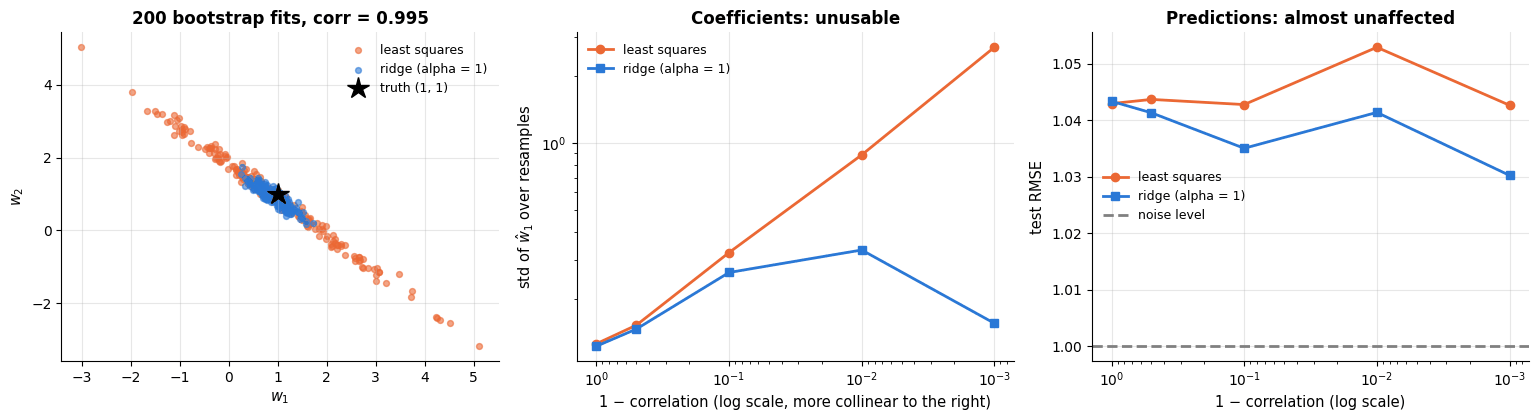

corr = 0.995: OLS coefficients range from -3.2 to 5.1 (sum w1+w2 stays at 1.85 ± 0.13);  ridge: 0.2 to 1.7


In [23]:
from sklearn.linear_model import ElasticNet

def collinear_sample(n, rho, gen):
    """Two features with correlation rho; the truth is y = x1 + x2 + noise.

    Draws from the random generator `gen`; returns X of shape (n, 2) and y of shape (n,).
    """
    x1 = gen.normal(size=n)
    x2 = rho * x1 + np.sqrt(1 - rho ** 2) * gen.normal(size=n)     # unit variance and correlation rho with x1
    X = np.c_[x1, x2]                                               # the two columns side by side, (n, 2)
    return X, X @ np.array([1.0, 1.0]) + gen.normal(0, 1.0, n)

rho_demo, n_demo, n_boot_demo = 0.995, 60, 200
X_col, y_col = collinear_sample(n_demo, rho_demo, rng)
coefs_ols, coefs_ridge = [], []
for _ in range(n_boot_demo):
    idx = rng.integers(0, n_demo, n_demo)          # a bootstrap resample: n_demo row indices drawn with replacement
    coefs_ols.append(LinearRegression().fit(X_col[idx], y_col[idx]).coef_)
    coefs_ridge.append(Ridge(alpha=1.0).fit(X_col[idx], y_col[idx]).coef_)
coefs_ols, coefs_ridge = np.array(coefs_ols), np.array(coefs_ridge)      # (200, 2) each

rhos = np.array([0.0, 0.5, 0.9, 0.99, 0.999])
sd_ols, sd_ridge, rmse_ols, rmse_ridge = [], [], [], []      # one value per rho
for r in rhos:
    sds_o, sds_r, errs_o, errs_r = [], [], [], []            # one value per dataset
    for _ in range(6):                                   # several independent datasets per rho
        X_tr_c, y_tr_c = collinear_sample(n_demo, r, rng)
        X_te_c, y_te_c = collinear_sample(2000, r, rng)
        c_o, c_r, e_o, e_r = [], [], [], []              # one value per resample
        for _ in range(40):                              # ... and bootstrap resamples within each
            idx = rng.integers(0, n_demo, n_demo)
            m_o = LinearRegression().fit(X_tr_c[idx], y_tr_c[idx])
            m_r = Ridge(alpha=1.0).fit(X_tr_c[idx], y_tr_c[idx])
            c_o.append(m_o.coef_[0]); c_r.append(m_r.coef_[0])      # ; separates two statements on one line
            e_o.append(root_mean_squared_error(y_te_c, m_o.predict(X_te_c)))
            e_r.append(root_mean_squared_error(y_te_c, m_r.predict(X_te_c)))
        sds_o.append(np.std(c_o)); sds_r.append(np.std(c_r))       # spread of w_1 over the resamples
        errs_o.append(np.mean(e_o)); errs_r.append(np.mean(e_r))
    # average over the 6 datasets
    sd_ols.append(np.mean(sds_o)); sd_ridge.append(np.mean(sds_r))
    rmse_ols.append(np.mean(errs_o)); rmse_ridge.append(np.mean(errs_r))

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.3))
axes[0].scatter(coefs_ols[:, 0], coefs_ols[:, 1], s=18, alpha=0.6, color=PALETTE[1], label="least squares")
axes[0].scatter(coefs_ridge[:, 0], coefs_ridge[:, 1], s=18, alpha=0.6, color=PALETTE[0], label="ridge (alpha = 1)")
axes[0].plot(1, 1, "*", color="black", ms=16, label="truth (1, 1)")
axes[0].set_xlabel("$w_1$")
axes[0].set_ylabel("$w_2$")
axes[0].set_title(f"200 bootstrap fits, corr = {rho_demo}")
axes[0].legend(fontsize=9)
# x-axis: 1 - rho on a log scale, inverted so that stronger collinearity lies further to the right
axes[1].plot(1 - rhos, sd_ols, marker="o", color=PALETTE[1], label="least squares")
axes[1].plot(1 - rhos, sd_ridge, marker="s", color=PALETTE[0], label="ridge (alpha = 1)")
axes[1].set_xscale("log"); axes[1].set_yscale("log")
axes[1].invert_xaxis()
axes[1].set_xlabel("1 − correlation (log scale, more collinear to the right)")
axes[1].set_ylabel("std of $\\hat w_1$ over resamples")
axes[1].set_title("Coefficients: unusable")
axes[1].legend(fontsize=9)
axes[2].plot(1 - rhos, rmse_ols, marker="o", color=PALETTE[1], label="least squares")
axes[2].plot(1 - rhos, rmse_ridge, marker="s", color=PALETTE[0], label="ridge (alpha = 1)")
axes[2].axhline(1.0, color="gray", ls="--", label="noise level")
axes[2].set_xscale("log")
axes[2].invert_xaxis()
axes[2].set_xlabel("1 − correlation (log scale)")
axes[2].set_ylabel("test RMSE")
axes[2].set_title("Predictions: almost unaffected")
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.show()
# .sum(axis=1) is w1 + w2 of each bootstrap fit
print(f"corr = {rho_demo}: OLS coefficients range from {coefs_ols.min():.1f} to {coefs_ols.max():.1f} "
      f"(sum w1+w2 stays at {coefs_ols.sum(axis=1).mean():.2f} ± {coefs_ols.sum(axis=1).std():.2f});  "
      f"ridge: {coefs_ridge.min():.1f} to {coefs_ridge.max():.1f}")

The left panel is the signature of collinearity: the least-squares estimates slide along
the anti-diagonal $w_1 + w_2 = \text{const}$ — the data pin down the *sum* precisely and
say almost nothing about the split — while ridge collapses the cloud onto the sensible
point near $(1, 1)$. The middle panel shows the standard deviation of $\hat w_1$ growing by
orders of magnitude as $\rho \to 1$; the right panel shows the test RMSE staying flat.

> **Warning.** "My model predicts well, so the coefficients must be right" is a false
> inference. Check the VIF (section 4.2) before you interpret a single coefficient, and
> prefer ridge when you must report numbers for correlated features.

### 9.4 Failure mode 3: the lasso's choice among correlated features is arbitrary

The lasso's selection is its selling point and its weakness. When three features carry
nearly the same information, the $\ell_1$ penalty has no reason to prefer one, so it keeps
whichever happens to correlate marginally better with the residual in *this* sample. Repeat
the fit on bootstrap resamples and the selected set changes. The elastic net's $\ell_2$
component removes the tie-break: correlated features enter together. To compare the two
fairly we match the $\ell_1$ part of the penalty — scikit-learn's elastic net penalises with
$\alpha\rho$ in $\ell_1$ and $\alpha(1-\rho)/2$ in $\ell_2$, so `alpha=2, l1_ratio=0.5`
applies exactly the same $\ell_1$ pressure as `Lasso(alpha=1)`, plus a ridge term.

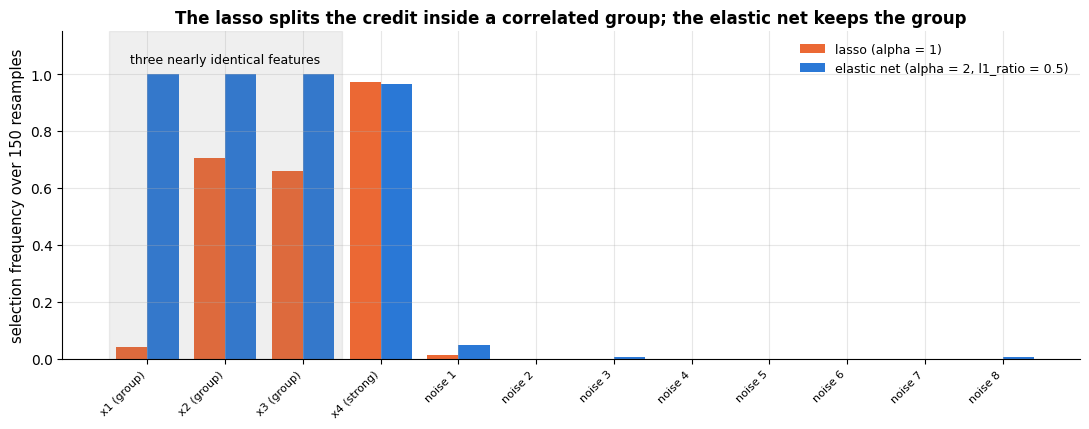

average number of the 3 group features selected — lasso: 1.41, elastic net: 3.00 (of 3)
average number of the 8 noise features selected — lasso: 0.01, elastic net: 0.06 (of 8)


In [24]:
d_grp, corr_grp = 12, 0.995
n_grp, n_rep = 80, 150
z_shared = rng.normal(size=n_grp)          # a common signal shared by the three group features
# three columns, each 0.995 * z_shared plus a little independent noise (so each pair correlates at about 0.99);
# the generator yields three arrays, tuple(...) collects them and np.c_ stacks them as columns -> shape (80, 3)
X_grp = np.c_[tuple(corr_grp * z_shared + np.sqrt(1 - corr_grp ** 2) * rng.normal(size=n_grp) for _ in range(3))]
X_grp = np.c_[X_grp, rng.normal(size=(n_grp, d_grp - 3))]          # 3 correlated + 1 strong + 8 noise
w_grp = np.r_[1.0, 1.0, 1.0, 2.0, np.zeros(d_grp - 4)]              # the true coefficients
y_grp = X_grp @ w_grp + rng.normal(0, 1.5, n_grp)

sel_lasso = np.zeros(d_grp)       # how often each feature gets selected
sel_enet = np.zeros(d_grp)
for _ in range(n_rep):
    idx = rng.integers(0, n_grp, n_grp)          # a bootstrap resample
    # the comparison is True (= 1) for every non-zero coefficient, so += counts the selections per feature
    sel_lasso += np.abs(Lasso(alpha=1.0).fit(X_grp[idx], y_grp[idx]).coef_) > 1e-8
    sel_enet += np.abs(ElasticNet(alpha=2.0, l1_ratio=0.5).fit(X_grp[idx], y_grp[idx]).coef_) > 1e-8
sel_lasso, sel_enet = sel_lasso / n_rep, sel_enet / n_rep      # counts -> selection frequencies

labels = ["x1 (group)", "x2 (group)", "x3 (group)", "x4 (strong)"] + [f"noise {i}" for i in range(1, d_grp - 3)]
pos = np.arange(d_grp)
fig, ax = plt.subplots(figsize=(11, 4.4))
# side-by-side bars, 0.4 wide: the lasso left of each position, the elastic net right of it
ax.bar(pos - 0.2, sel_lasso, width=0.4, color=PALETTE[1], label="lasso (alpha = 1)")
ax.bar(pos + 0.2, sel_enet, width=0.4, color=PALETTE[0], label="elastic net (alpha = 2, l1_ratio = 0.5)")
ax.axvspan(-0.5, 2.5, color="gray", alpha=0.12)      # shade the three group features
ax.text(1.0, 1.04, "three nearly identical features", ha="center", fontsize=9)
ax.set_xticks(pos)
ax.set_xticklabels(labels, rotation=45, ha="right", fontsize=8)     # rotated labels, aligned at their right end
ax.set_ylabel(f"selection frequency over {n_rep} resamples")
ax.set_ylim(0, 1.15)
ax.set_title("The lasso splits the credit inside a correlated group; the elastic net keeps the group")
ax.legend(loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()
# [:3] are the three group features and [4:] the eight noise features; summing frequencies gives an average count
print(f"average number of the 3 group features selected — lasso: {sel_lasso[:3].sum():.2f}, "
      f"elastic net: {sel_enet[:3].sum():.2f} (of 3)")
print(f"average number of the 8 noise features selected — lasso: {sel_lasso[4:].sum():.2f}, "
      f"elastic net: {sel_enet[4:].sum():.2f} (of 8)")

Both methods find the strong independent feature every time and both keep the eight noise
features out — the $\ell_1$ pressure is identical, after all. The difference is inside the
correlated group: the lasso keeps only about one and a half of the three, and *which* ones
it keeps is a property of the sample rather than of the world — here it almost never keeps
`x1` and splits the rest between `x2` and `x3` — while the elastic net keeps all three in
essentially every resample. If your next step is "these are the three biomarkers that matter", the lasso's
answer is a coin flip and the elastic net's is stable. The cost of the $\ell_2$ term is
that with a smaller `l1_ratio` the selection pressure weakens and noise features start to
slip back in — which is exactly the trade-off `l1_ratio` controls, and section 10 tunes it.

### 9.5 Choosing among them

In practice the decision is short. **Standardise, then start with ridge**; it is never a
disaster and it is the only one of the four with a free leave-one-out tuning shortcut. Move
to the **lasso** when you want to hand someone a model with five features instead of five
hundred, and to the **elastic net** when the features are both many and correlated. Keep
plain **OLS** for the case it was designed for — modest $d$, uncorrelated features, and a
need for honest standard errors — and remember the failures that are *not* fixed by any
penalty: curvature (9.2, fixed by the feature basis), gross outliers (section 5.2, fixed by
a robust loss), and non-Gaussian targets such as counts (section 8, fixed by a GLM).

## 10. Tuning guide

### 10.1 What the knobs do

| Parameter | Model | What it controls | Range / scale | Bias–variance | Default |
|---|---|---|---|---|---|
| `alpha` ($\lambda$) | `Ridge`, `Lasso`, `ElasticNet` | strength of the penalty | $10^{-4} \dots 10^{4}$, **log** grid of 20–40 points | ↑ alpha → more bias, less variance | `1.0` (almost never right — always tune) |
| `l1_ratio` ($\rho$) | `ElasticNet` | share of $\ell_1$ in the mixed penalty: 0 = ridge, 1 = lasso | $\{0.1, 0.5, 0.7, 0.9, 0.95, 0.99, 1\}$ — denser near 1 | ↑ ratio → sparser, higher variance in *which* features | `0.5` |
| `degree` | `PolynomialFeatures` | order of the polynomial basis | 1–3 (rarely more) | ↑ degree → less bias, much more variance | `2` |
| `n_knots`, `degree` | `SplineTransformer` | number and smoothness of local bumps | knots 4–20, degree 3 | ↑ knots → less bias, more variance (tame it with `alpha`) | `5`, `3` |
| standardisation | `StandardScaler` | the *units* the penalty sees | on / off | not a bias–variance knob: **mandatory** for penalised models | — |
| `solver` | `Ridge` | which linear algebra routine | `auto`, `svd`, `cholesky`, `lsqr`, `sparse_cg`, `sag`, `saga` | none — identical solution | `auto` |
| `max_iter`, `tol` | `Lasso`, `ElasticNet`, `SGDRegressor` | when coordinate descent stops | raise until `ConvergenceWarning`s disappear | none if converged | `1000`, `1e-4` |
| `fit_intercept` | all | whether $b$ is fitted (and left unpenalised) | on / off | leave on | `True` |
| `positive` | `Ridge`, `Lasso` | force $w_j \ge 0$ | on / off | a hard constraint, use only when physics demands it | `False` |

### 10.2 Tune in this order

1. **Standardise** — not a tuning decision but a precondition. A penalty on $\|\mathbf{w}\|$
   is a statement about units; without a common scale, `alpha` means something different
   for every feature (section 7.1).
2. **Choose the feature basis** (raw / splines / interactions). This changes the model class
   and dwarfs everything else, and it **interacts with `alpha`**: a richer basis needs a
   larger penalty. Tune the pair jointly, not one after the other (10.4).
3. **`alpha`** on a log grid. This is the single most important number; everything else is
   a refinement.
4. **`l1_ratio`**, only for the elastic net, on a coarse grid weighted towards 1.
5. **Nothing else.** The solver, `tol`, `max_iter`, `precompute` and `selection` change the
   runtime, not the answer; `fit_intercept` should stay on.

### 10.3 Validation curves for `alpha`

The reliable picture for a single hyper-parameter is a validation curve: cross-validated
error against the parameter on a log axis, with a $\pm$ 1 standard-error band (notebook 5,
section 6). We draw it for ridge and for the lasso on the diabetes data and add, for the
lasso, the number of surviving features — the reason you would choose it in the first place.

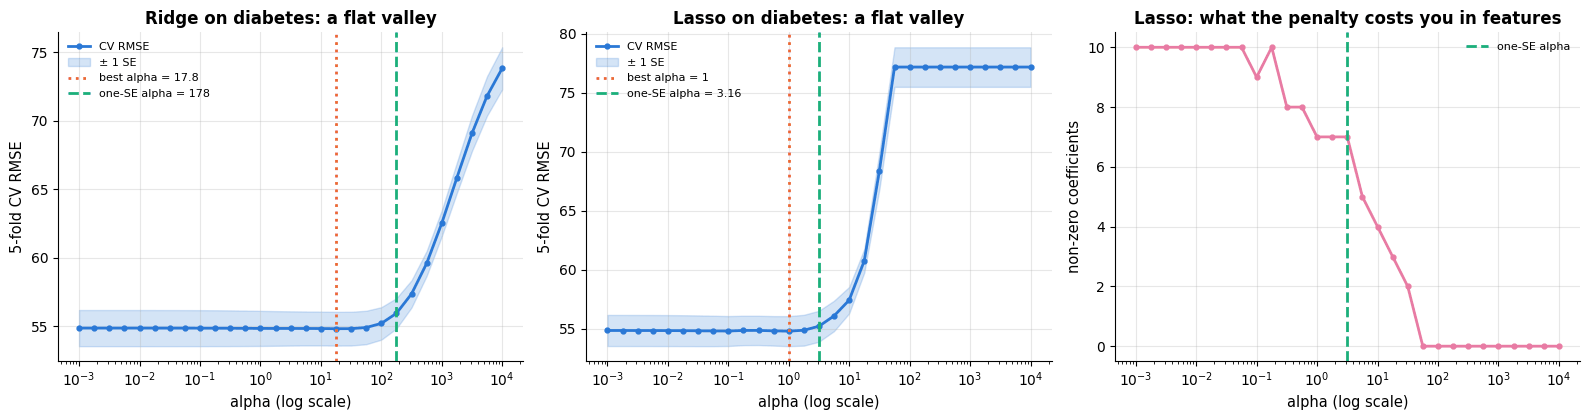

ridge: best alpha    17.8 (CV RMSE 54.81 ± 1.23)   one-SE alpha     178 (CV RMSE 55.93)
lasso: best alpha       1 (CV RMSE 54.79 ± 1.27)   one-SE alpha    3.16 (CV RMSE 55.21)
the lasso keeps 7 features at its best alpha and 7 at the one-SE alpha (of 10)


In [25]:
from sklearn.model_selection import GridSearchCV      # exhaustive grid search with CV (used in section 11.2)

def cv_curve(make_model, values, X, y, cv=None):
    """Mean and standard error of the CV RMSE for every value of one hyper-parameter.

    make_model   function that takes one parameter value and returns a fresh, unfitted model
    values       the parameter values to try
    cv           a CV splitter; None means the notebook's 5-fold `kf`
    Returns two arrays (means, standard errors), one entry per value.
    """
    cv = cv if cv is not None else kf
    means, ses = [], []
    for v in values:
        scores = -cross_val_score(make_model(v), X, y, cv=cv, scoring="neg_root_mean_squared_error")
        means.append(scores.mean())
        ses.append(scores.std(ddof=1) / np.sqrt(len(scores)))      # standard error of the mean over the folds
    return np.array(means), np.array(ses)

def one_se_choice(values, means, ses):
    """Largest (most regularised) value whose CV error is within one SE of the best.

    Works with positions and assumes `values` runs from the weakest to the strongest penalty. Returns the pair
    (index of the lowest mean error, largest index whose mean error is at most that minimum plus its SE).
    """
    best = int(np.argmin(means))
    ok = np.where(means <= means[best] + ses[best])[0]       # np.where(cond)[0]: the positions where cond is True
    return best, int(ok.max())

alpha_grid = np.logspace(-3, 4, 29)        # 29 alphas from 10^-3 to 10^4
# `lambda a: ...` builds a new pipeline for a given alpha a; max_iter=10000 gives the lasso solver room to converge
ridge_mean, ridge_se = cv_curve(lambda a: make_pipeline(StandardScaler(), Ridge(alpha=a)), alpha_grid, X_diab, y_diab)
lasso_mean, lasso_se = cv_curve(lambda a: make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000)),
                                alpha_grid, X_diab, y_diab)
# number of non-zero lasso coefficients after fitting on all rows, for every alpha ([-1] is the Lasso step)
n_selected = [int((np.abs(make_pipeline(StandardScaler(), Lasso(alpha=a, max_iter=10000))
                          .fit(X_diab, y_diab)[-1].coef_) > 1e-8).sum()) for a in alpha_grid]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
# zip stops after the two (name, mean, se) triples, so the third panel is drawn separately below
for ax, (name, mean, se) in zip(axes, [("Ridge", ridge_mean, ridge_se), ("Lasso", lasso_mean, lasso_se)]):
    best, one_se = one_se_choice(alpha_grid, mean, se)
    ax.plot(alpha_grid, mean, marker="o", ms=3.5, color=PALETTE[0], label="CV RMSE")
    ax.fill_between(alpha_grid, mean - se, mean + se, color=PALETTE[0], alpha=0.2, label="± 1 SE")   # shaded band
    ax.axvline(alpha_grid[best], color=PALETTE[1], ls=":", label=f"best alpha = {alpha_grid[best]:.3g}")
    ax.axvline(alpha_grid[one_se], color=PALETTE[2], ls="--", label=f"one-SE alpha = {alpha_grid[one_se]:.3g}")
    ax.set_xscale("log")
    ax.set_xlabel("alpha (log scale)")
    ax.set_ylabel("5-fold CV RMSE")
    ax.set_title(f"{name} on diabetes: a flat valley")
    ax.legend(fontsize=8, loc="upper left")
axes[2].plot(alpha_grid, n_selected, marker="o", ms=3.5, color=PALETTE[4])
# [1] picks the one-SE index from the pair returned by one_se_choice
axes[2].axvline(alpha_grid[one_se_choice(alpha_grid, lasso_mean, lasso_se)[1]], color=PALETTE[2], ls="--",
                label="one-SE alpha")
axes[2].set_xscale("log")
axes[2].set_xlabel("alpha (log scale)")
axes[2].set_ylabel("non-zero coefficients")
axes[2].set_title("Lasso: what the penalty costs you in features")
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()
for name, mean, se in [("ridge", ridge_mean, ridge_se), ("lasso", lasso_mean, lasso_se)]:
    b, o = one_se_choice(alpha_grid, mean, se)
    # :7.3g = width 7, 3 significant digits
    print(f"{name}: best alpha {alpha_grid[b]:7.3g} (CV RMSE {mean[b]:.2f} ± {se[b]:.2f})   "
          f"one-SE alpha {alpha_grid[o]:7.3g} (CV RMSE {mean[o]:.2f})")
print(f"the lasso keeps {n_selected[one_se_choice(alpha_grid, lasso_mean, lasso_se)[0]]} features at its best alpha "
      f"and {n_selected[one_se_choice(alpha_grid, lasso_mean, lasso_se)[1]]} at the one-SE alpha (of {len(feature_names)})")

Read three things off these curves. First, the **valley is flat**: over three decades of
`alpha` the CV RMSE moves by less than one standard error (about 1.2 points on an RMSE of
55), which is typical when $n \gg d$ and the model is not over-parametrised. The honest
conclusion is "any `alpha` between roughly 1 and 100 is fine", not "the optimum is 17.8".
Second, the **one-standard-error rule** exploits exactly that flatness: it moves the ridge
penalty an order of magnitude higher, and the lasso penalty three times higher, for about
one point of RMSE — a cheaper, more stable model at a cost you can barely measure. Third,
the right-hand panel shows what the lasso's penalty actually buys: the feature count is a
*step function* of `alpha` — all ten features up to `alpha` ≈ 0.3, seven around the one-SE
choice, three by `alpha` ≈ 20 — and not even a monotone one: between two neighbouring grid
points coordinate descent can drop a feature and re-admit it. If the minimum had sat at either *end* of the grid the grid
would have been too narrow — extend it and refit.

### 10.4 Two parameters that interact: a 2-D CV heat-map

`alpha` and `l1_ratio` interact, and so do `alpha` and the richness of the basis: each
controls how much the model is allowed to wiggle, so the best value of one depends on the
other. One-at-a-time tuning walks into the wrong corner of such a surface; a small grid
search and a heat-map show the whole picture. The left panel uses the sparse
correlated problem from section 7.4 ($n = 100$, $d = 40$), the right one splines on the
diabetes data.

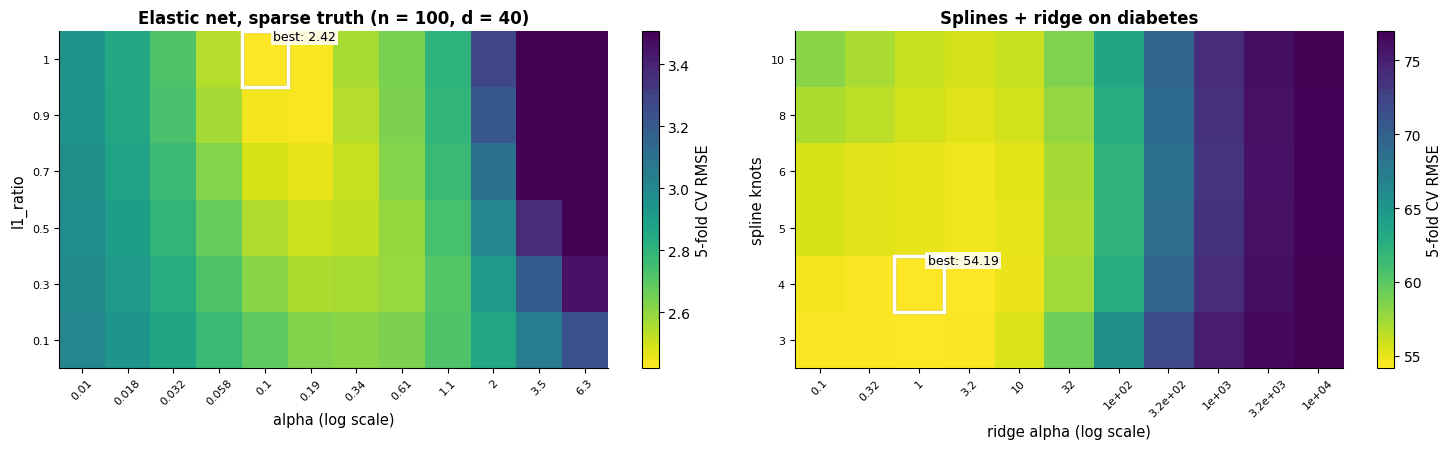

elastic net: best CV RMSE 2.421 at alpha = 0.104, l1_ratio = 1
splines: best CV RMSE 54.19 at alpha = 1, knots = 4


In [26]:
X_sparse, y_sparse = make_correlated_regression(100, truths["sparse truth (5 of 40 non-zero)"])    # a fresh sample

enet_alphas = np.logspace(-2, 0.8, 12)
l1_ratios = np.array([0.1, 0.3, 0.5, 0.7, 0.9, 1.0])
# nested list comprehension -> 2-D array of CV RMSEs: one row per l1_ratio, one column per alpha
enet_grid = np.array([[-cross_val_score(make_pipeline(StandardScaler(), ElasticNet(alpha=a, l1_ratio=r, max_iter=20000)),
                                        X_sparse, y_sparse, cv=kf, scoring="neg_root_mean_squared_error").mean()
                       for a in enet_alphas] for r in l1_ratios])

knot_values = np.array([3, 4, 5, 6, 8, 10])
spline_alphas = np.logspace(-1, 4, 11)
# the same for splines + ridge on the diabetes data: one row per number of knots, one column per ridge alpha
spline_grid = np.array([[-cross_val_score(make_pipeline(StandardScaler(), SplineTransformer(n_knots=k), Ridge(alpha=a)),
                                          X_diab, y_diab, cv=kf, scoring="neg_root_mean_squared_error").mean()
                         for a in spline_alphas] for k in knot_values])

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for ax, (grid_vals, xs, ys, xlabel, ylabel, title) in zip(axes, [
        (enet_grid, enet_alphas, l1_ratios, "alpha (log scale)", "l1_ratio", "Elastic net, sparse truth (n = 100, d = 40)"),
        (spline_grid, spline_alphas, knot_values, "ridge alpha (log scale)", "spline knots", "Splines + ridge on diabetes")]):
    # imshow draws the grid as coloured cells; "viridis_r" is viridis reversed, so low errors are bright;
    # origin="lower" puts row 0 at the bottom
    im = ax.imshow(grid_vals, cmap="viridis_r", aspect="auto", origin="lower")
    ax.set_xticks(range(len(xs)), [f"{v:.2g}" for v in xs], rotation=45, fontsize=8)   # :.2g = 2 significant digits
    ax.set_yticks(range(len(ys)), [f"{v:g}" for v in ys], fontsize=8)                  # :g drops trailing zeros
    # np.argmin gives a position in the flattened array; np.unravel_index turns it into (row, column)
    i_best, j_best = np.unravel_index(np.argmin(grid_vals), grid_vals.shape)
    ax.add_patch(plt.Rectangle((j_best - 0.5, i_best - 0.5), 1, 1, fill=False, edgecolor="white", lw=2.5))
    # textcoords="offset points": xytext is an offset in points from xy; bbox draws a white box behind the text
    ax.annotate(f"best: {grid_vals[i_best, j_best]:.2f}", xy=(j_best, i_best), xytext=(6, 14),
                textcoords="offset points", color="black", fontsize=9,
                bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.85, "pad": 1.5})
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.grid(False)
    plt.colorbar(im, ax=ax, label="5-fold CV RMSE")      # the colour scale next to this panel
plt.tight_layout()
plt.show()
print(f"elastic net: best CV RMSE {enet_grid.min():.3f} at alpha = {enet_alphas[np.unravel_index(np.argmin(enet_grid), enet_grid.shape)[1]]:.3g}, "
      f"l1_ratio = {l1_ratios[np.unravel_index(np.argmin(enet_grid), enet_grid.shape)[0]]:g}")
print(f"splines: best CV RMSE {spline_grid.min():.2f} at alpha = {spline_alphas[np.unravel_index(np.argmin(spline_grid), spline_grid.shape)[1]]:.3g}, "
      f"knots = {knot_values[np.unravel_index(np.argmin(spline_grid), spline_grid.shape)[0]]:g}")

Both surfaces are **diagonal ridges, not bowls**. In the left panel the best `alpha` moves
as `l1_ratio` changes — a mostly-$\ell_1$ penalty of a given strength shrinks more than a
mostly-$\ell_2$ one, so the two must move together. In the right panel more knots demand a
larger `alpha`; along the diagonal the error is nearly constant, which is the practical
message: *there are many equally good (basis, penalty) pairs, and you should pick the
simplest one on the ridge*, not the single cell with the lowest number.

### 10.5 What the parameter does to the fitted function

A validation curve says which `alpha` is best; it does not say what `alpha` *is*. For a
model whose shape you can draw — splines on one feature — plot the fit across the range of
the parameter and the abstraction disappears.

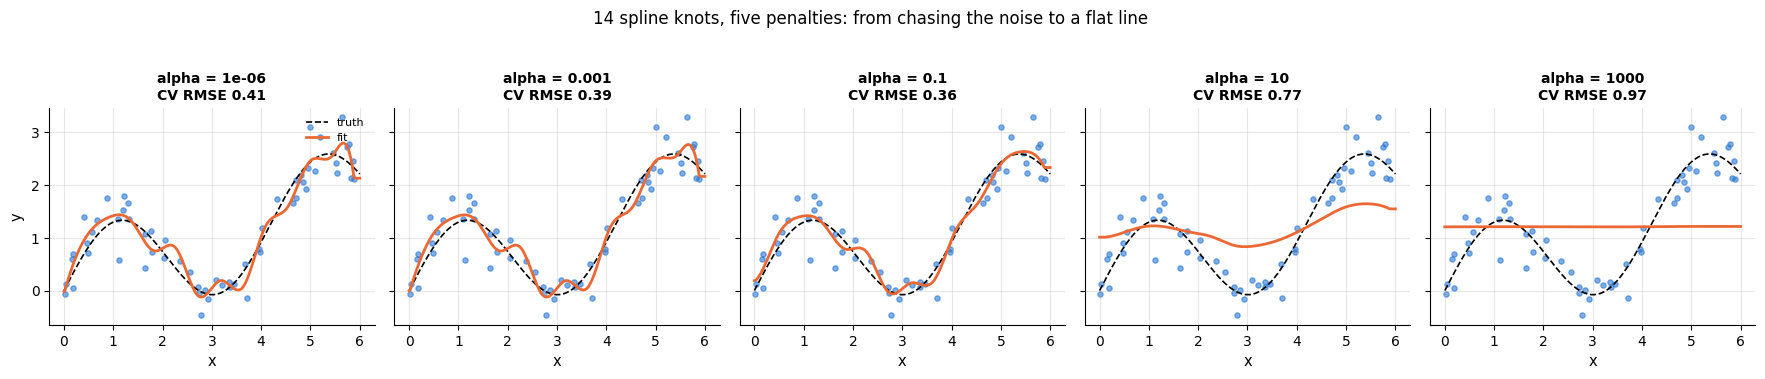

In [27]:
alphas_shape = [1e-6, 1e-3, 1e-1, 10.0, 1e3]       # five penalties, from almost none to very strong
curve_grid = np.linspace(0, 6, 300)[:, None]
fig, axes = plt.subplots(1, 5, figsize=(18, 3.6), sharey=True)
for ax, a in zip(axes, alphas_shape):
    # 14 knots is a deliberately generous basis for 60 points; the ridge penalty a decides how wiggly the fit is
    model = make_pipeline(SplineTransformer(n_knots=14, degree=3), Ridge(alpha=a)).fit(x_curve[:, None], y_curve)
    cv_rmse = -cross_val_score(make_pipeline(SplineTransformer(n_knots=14, degree=3), Ridge(alpha=a)),
                               x_curve[:, None], y_curve, cv=kf, scoring="neg_root_mean_squared_error").mean()
    ax.scatter(x_curve, y_curve, s=14, alpha=0.6, color=PALETTE[0])
    ax.plot(curve_grid, truth(curve_grid), color="black", ls="--", lw=1.2, label="truth")
    ax.plot(curve_grid, model.predict(curve_grid), color=PALETTE[1], lw=2, label="fit")
    ax.set_title(f"alpha = {a:g}\nCV RMSE {cv_rmse:.2f}", fontsize=10)
    ax.set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(fontsize=8, loc="upper right")
fig.suptitle("14 spline knots, five penalties: from chasing the noise to a flat line", y=1.04)
plt.tight_layout()
plt.show()

Left to right the same model goes from following every noise point (variance) to a nearly
straight line (bias), with the good compromises in the middle — the bias–variance picture of
notebook 5, produced here by a penalty rather than by changing the number of features. Note
that with 14 knots and 60 points the *unpenalised* fit would be hopeless; regularisation is
what makes a generous basis safe.

### 10.6 Practical notes

- **The optimum sits at the edge of the grid.** Extend the grid until it does not. A best
  `alpha` at the smallest value means "no penalty needed"; at the largest, "this feature set
  is useless" — both are findings, not settings.
- **The curve is flat.** Apply the one-standard-error rule (10.3): take the strongest
  penalty within one SE of the best. It costs nothing measurable and buys stability and,
  for the lasso, sparsity.
- **Runtime.** Tuning `alpha` for ridge is essentially free — `RidgeCV` computes the
  leave-one-out error for every `alpha` from a single SVD. `LassoCV` and `ElasticNetCV` fit
  a whole path with warm starts, which costs a small multiple of one fit. The expensive
  object is the 2-D grid of 10.4: $|{\tt alpha}| \times |{\tt l1\_ratio}| \times k$ fits.
- **Do not tune the solver.** Here is the evidence: identical coefficients, different times.
- **Tune inside a pipeline, evaluate outside it.** The scaler must be fitted on each
  training fold (notebook 4), and a score taken on the same folds that chose `alpha` is
  optimistic; use nested CV or a held-out test set (notebook 12).

In [28]:
solver_rows = []
# the same ridge problem solved by five different linear-algebra routines
for solver in ["svd", "cholesky", "lsqr", "sparse_cg", "sag"]:
    t0 = time.perf_counter()          # a high-resolution clock, in seconds
    # max_iter and tol only matter for the iterative solvers (lsqr, sparse_cg, sag); tol=1e-8 asks for high accuracy
    model = Ridge(alpha=10.0, solver=solver, max_iter=100000, tol=1e-8).fit(Xs, yd)
    solver_rows.append({"solver": solver, "time (ms)": 1000 * (time.perf_counter() - t0),
                        # the largest coefficient difference from the svd solver's answer
                        "max |w − w_svd|": np.abs(model.coef_ - Ridge(alpha=10.0, solver="svd").fit(Xs, yd).coef_).max(),
                        "CV RMSE": -cross_val_score(Ridge(alpha=10.0, solver=solver, max_iter=100000, tol=1e-8),
                                                    Xs, yd, cv=kf, scoring="neg_root_mean_squared_error").mean()})
# .round({column: decimals}) rounds each column to its own number of decimals
pd.DataFrame(solver_rows).set_index("solver").round({"time (ms)": 2, "max |w − w_svd|": 12, "CV RMSE": 4})

,time (ms),max |w − w_svd|,CV RMSE
solver,,,
svd,1.03,0.000000e+00,54.8175
cholesky,0.65,0.000000e+00,54.8175
lsqr,1.06,3.814800e-08,54.8175
sparse_cg,0.81,0.000000e+00,54.8175
sag,2.51,3.122560e-07,54.8175


The five solvers agree to seven decimals or better — the differences are the iteration
tolerances of the iterative ones, not different answers. Choose `svd` for tiny, ill-conditioned
problems, `sparse_cg`/`lsqr` for large sparse matrices, `sag`/`saga` for very large $n$ —
and never expect a different answer.

## 11. Case study on real data: diabetes progression

Time to run the whole workflow end to end on a **real** dataset. The diabetes data (Efron
et al., 2004) are 442 patients from a study of disease progression: ten baseline
measurements — age, sex, body-mass index, mean arterial blood pressure and six blood serum
measurements — and, as target, a quantitative measure of disease progression one year after
baseline. We use the raw units (`scaled=False`) so that the final coefficients mean
something to a clinician. This is a small, noisy, thoroughly studied dataset: exactly the
situation in which a regularised linear model is the right tool and a complicated one is
not.

### 11.1 Split, baseline, and a first comparison

The split was made back in section 5.1 (`Xtr`, `Xte`, `ytr`, `yte`: 331 training and 111
test patients). Every model is a **pipeline** whose scaler is fitted inside each
cross-validation fold, every score is 5-fold CV **on the training set only**, and the test
set stays untouched until section 11.3. The first question is always the same: *does
anything beat predicting the mean?*

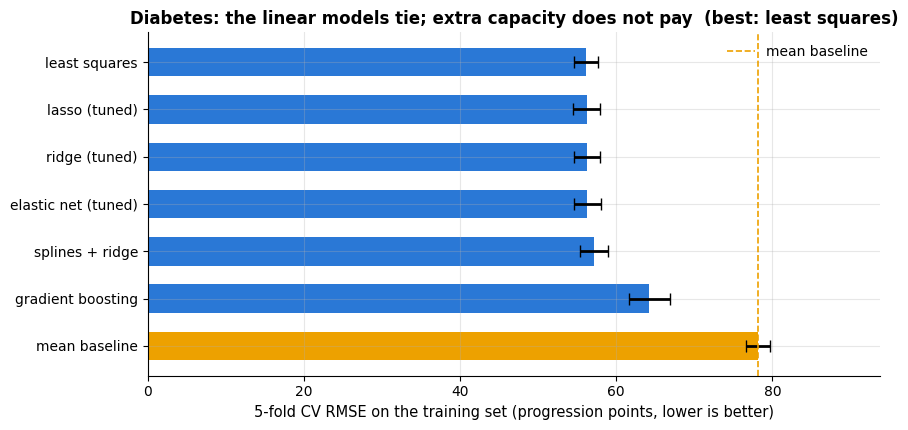

,CV RMSE,SE
model,,
mean baseline,78.14,1.56
least squares,56.12,1.57
ridge (tuned),56.27,1.65
lasso (tuned),56.24,1.73
elastic net (tuned),56.32,1.73
splines + ridge,57.12,1.79
gradient boosting,64.23,2.64


In [29]:
from sklearn.ensemble import HistGradientBoostingRegressor     # gradient-boosted trees (notebook 10)

case_models = {
    "mean baseline": DummyRegressor(strategy="mean"),
    "least squares": make_pipeline(StandardScaler(), LinearRegression()),
    "ridge (tuned)": make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(-3, 4, 40))),
    "lasso (tuned)": make_pipeline(StandardScaler(), LassoCV(cv=kf, max_iter=10000, random_state=RANDOM_STATE)),
    # a list of l1_ratio values makes ElasticNetCV tune l1_ratio as well as alpha
    "elastic net (tuned)": make_pipeline(StandardScaler(), ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0],
                                                                       cv=kf, max_iter=10000, random_state=RANDOM_STATE)),
    # SplineTransformer gives every feature its own spline basis (5 knots each)
    "splines + ridge": make_pipeline(StandardScaler(), SplineTransformer(n_knots=5), RidgeCV(alphas=np.logspace(-1, 4, 40))),
    # 120 boosting iterations of trees with at most 15 leaves each
    "gradient boosting": HistGradientBoostingRegressor(max_iter=120, max_leaf_nodes=15, random_state=RANDOM_STATE),
}
case_rows = []
for name, model in case_models.items():
    # 5-fold CV on the training patients only; the test set stays untouched
    scores = -cross_val_score(model, Xtr, ytr, cv=kf, scoring="neg_root_mean_squared_error")
    case_rows.append({"model": name, "CV RMSE": scores.mean(), "SE": scores.std(ddof=1) / np.sqrt(len(scores))})
case_df = pd.DataFrame(case_rows).set_index("model")

fig, ax = plt.subplots(figsize=(9, 4.4))
# worst first: barh draws the first row at the bottom, so the best model ends up at the top
order = case_df.sort_values("CV RMSE", ascending=False)
colors = [PALETTE[3] if m == "mean baseline" else PALETTE[0] for m in order.index]     # the baseline in its own colour
ax.barh(order.index, order["CV RMSE"], xerr=order["SE"], color=colors, height=0.6, capsize=4)
ax.axvline(order.loc["mean baseline", "CV RMSE"], color=PALETTE[3], ls="--", lw=1.2, label="mean baseline")
best_name = case_df["CV RMSE"].idxmin()       # .idxmin() returns the index label (model name) of the smallest value
ax.set_xlabel("5-fold CV RMSE on the training set (progression points, lower is better)")
ax.set_title(f"Diabetes: the linear models tie; extra capacity does not pay  (best: {best_name})")
ax.set_xlim(0, order["CV RMSE"].max() * 1.2)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()
display(case_df.round(2))

The baseline (predicting the training mean) has a CV RMSE of about 78 progression points —
that is simply the standard deviation of the target. Every linear model brings it down to
about 56, a 28 % reduction, and **they are all within one standard error of each other**:
plain least squares, ridge, the lasso and the elastic net are indistinguishable here,
because with $n = 331$ and only ten features there is little variance for a penalty to
remove. Gradient boosting, with far more capacity, is clearly *worse* (about 64): the extra
flexibility buys variance, not signal. The ceiling on this dataset is set by noise, not by
model class — a result worth reporting honestly rather than hiding behind whichever model
happened to score best.

### 11.2 Tuning with the guide from section 10

Following the order of 10.2: the basis stays raw (the splines did not help), so only
`alpha` and `l1_ratio` remain. We search them jointly on the training set with
`GridSearchCV`, then apply the one-standard-error idea by hand, which here means preferring
a simpler, more strongly penalised model whose CV error is statistically indistinguishable.

In [30]:
# keys are "<step>__<parameter>"; make_pipeline names each step after its class in lower case ("elasticnet")
param_grid = {"elasticnet__alpha": np.logspace(-3, 1.5, 20),
              "elasticnet__l1_ratio": [0.1, 0.5, 0.7, 0.9, 0.95, 1.0]}
# GridSearchCV cross-validates every combination (20 alphas x 6 l1_ratios) and refits the best on all of Xtr;
# n_jobs=1 runs on a single CPU core
search = GridSearchCV(make_pipeline(StandardScaler(), ElasticNet(max_iter=20000)), param_grid,
                      cv=kf, scoring="neg_root_mean_squared_error", n_jobs=1).fit(Xtr, ytr)
res = pd.DataFrame(search.cv_results_)      # one row per combination: param_..., mean_test_score, std_test_score, ...
best_rmse = -res["mean_test_score"].max()   # the scores are negated RMSEs, so the best one is the maximum
# standard error of the best combination: its std over the folds / sqrt(number of folds); .idxmax() is its row label
best_se = res.loc[res["mean_test_score"].idxmax(), "std_test_score"] / np.sqrt(kf.get_n_splits())
within = res[-res["mean_test_score"] <= best_rmse + best_se]        # all combinations within one SE of the best
# the most regularised of them = the row with the largest alpha (the param_ columns have object dtype, hence astype)
one_se_row = within.loc[within["param_elasticnet__alpha"].astype(float).idxmax()]
print(f"best:    alpha = {search.best_params_['elasticnet__alpha']:.4g}, "
      f"l1_ratio = {search.best_params_['elasticnet__l1_ratio']}, CV RMSE = {best_rmse:.2f} ± {best_se:.2f}")
print(f"one-SE:  alpha = {float(one_se_row['param_elasticnet__alpha']):.4g}, "
      f"l1_ratio = {one_se_row['param_elasticnet__l1_ratio']}, CV RMSE = {-one_se_row['mean_test_score']:.2f}")

# refit the chosen one-SE configuration on all training patients
final_model = make_pipeline(StandardScaler(), ElasticNet(alpha=float(one_se_row["param_elasticnet__alpha"]),
                                                         l1_ratio=float(one_se_row["param_elasticnet__l1_ratio"]),
                                                         max_iter=20000)).fit(Xtr, ytr)
kept = np.abs(final_model[-1].coef_) > 1e-8          # True for the features with a non-zero coefficient
# indexing an array of names with the True/False mask keeps the selected names
print(f"the one-SE model keeps {kept.sum()} of {len(feature_names)} features: "
      f"{', '.join(np.array(feature_names)[kept])}")

best:    alpha = 0.1354, l1_ratio = 1.0, CV RMSE = 56.06 ± 1.44
one-SE:  alpha = 3.57, l1_ratio = 0.95, CV RMSE = 57.46
the one-SE model keeps 6 of 10 features: sex, bmi, bp, s3, s5, s6


### 11.3 Honest evaluation on the held-out patients

Now, and only now, the test set. Three diagnostics tell the story: predicted against
observed (is the model biased anywhere?), residuals against predictions (is there
structure left?), and the distribution of the errors (how large is a typical miss?).

test RMSE: final model 52.78  vs. mean baseline 74.88
test MAE:  42.18 progression points;  test R² = 0.496
target range in the test set: 37 – 310, standard deviation 74.7


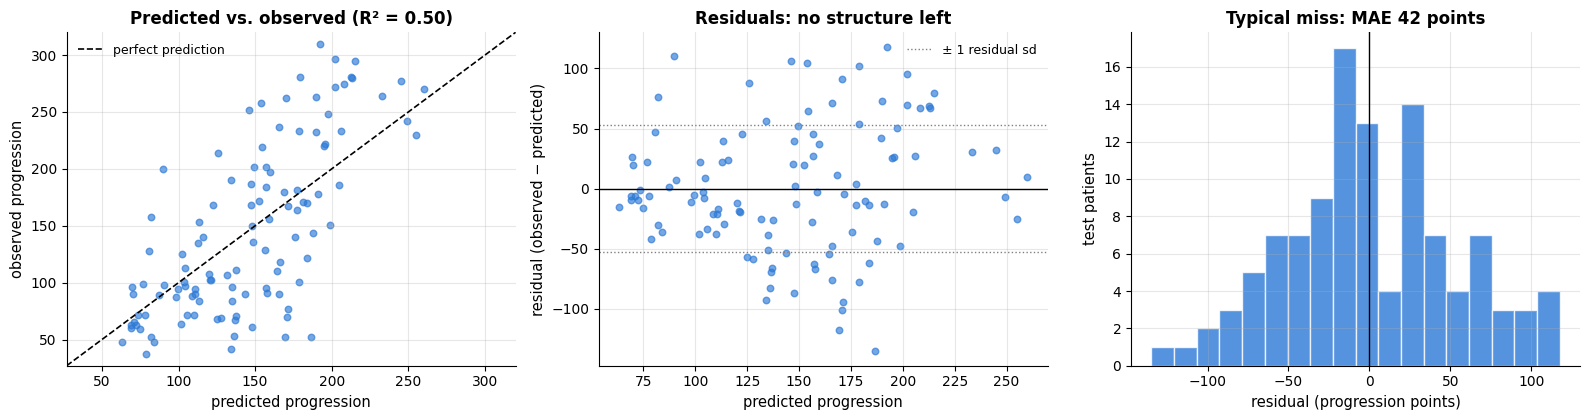

In [31]:
pred_test = final_model.predict(Xte)
resid_test = yte - pred_test
base_test = DummyRegressor(strategy="mean").fit(Xtr, ytr).predict(Xte)    # the training mean for every test patient
print(f"test RMSE: final model {root_mean_squared_error(yte, pred_test):.2f}  vs. mean baseline {root_mean_squared_error(yte, base_test):.2f}")
print(f"test MAE:  {mean_absolute_error(yte, pred_test):.2f} progression points;  test R² = {r2_score(yte, pred_test):.3f}")
print(f"target range in the test set: {yte.min():.0f} – {yte.max():.0f}, standard deviation {yte.std():.1f}")

fig, axes = plt.subplots(1, 3, figsize=(16, 4.3))
# common axis limits with a 10-point margin, so the diagonal y = x runs from corner to corner
lims = [min(yte.min(), pred_test.min()) - 10, max(yte.max(), pred_test.max()) + 10]
axes[0].scatter(pred_test, yte, s=22, alpha=0.65, color=PALETTE[0])
axes[0].plot(lims, lims, color="black", ls="--", lw=1.2, label="perfect prediction")   # the line observed = predicted
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("predicted progression")
axes[0].set_ylabel("observed progression")
axes[0].set_title(f"Predicted vs. observed (R² = {r2_score(yte, pred_test):.2f})")
axes[0].legend(fontsize=9)
axes[1].scatter(pred_test, resid_test, s=22, alpha=0.65, color=PALETTE[0])
axes[1].axhline(0, color="black", lw=1)
# dotted lines at plus and minus one standard deviation of the residuals
axes[1].axhline(resid_test.std(), color="gray", ls=":", lw=1, label="± 1 residual sd")
axes[1].axhline(-resid_test.std(), color="gray", ls=":", lw=1)
axes[1].set_xlabel("predicted progression")
axes[1].set_ylabel("residual (observed − predicted)")
axes[1].set_title("Residuals: no structure left")
axes[1].legend(fontsize=9)
axes[2].hist(resid_test, bins=18, color=PALETTE[0], alpha=0.8, edgecolor="white")
axes[2].axvline(0, color="black", lw=1)
axes[2].set_xlabel("residual (progression points)")
axes[2].set_ylabel("test patients")
axes[2].set_title(f"Typical miss: MAE {mean_absolute_error(yte, pred_test):.0f} points")
plt.tight_layout()
plt.show()

The model explains about half the variance of the held-out patients, the residual band is
shapeless — no curvature, no funnel — and the errors are roughly symmetric with a typical
size of 42 points. The one thing to notice in the left panel is that the cloud is tilted
slightly *flatter* than the diagonal: a penalised model pulls its predictions towards the
mean, so the patients who progress most are under-predicted and those who progress least
are over-predicted. That is the bias half of the bias–variance trade we accepted when we
chose the one-standard-error model, and it is the right trade here — but it means the model
should never be used to rank the extremes against each other.

### 11.4 What the coefficients say, in the original units

The final model was fitted on standardised features, so to speak to a clinician we convert
each coefficient back: dividing a standardised coefficient by the feature's standard
deviation gives the effect of **one unit of the original measurement**. Bootstrap intervals
carry the uncertainty, which is substantial with 331 patients.

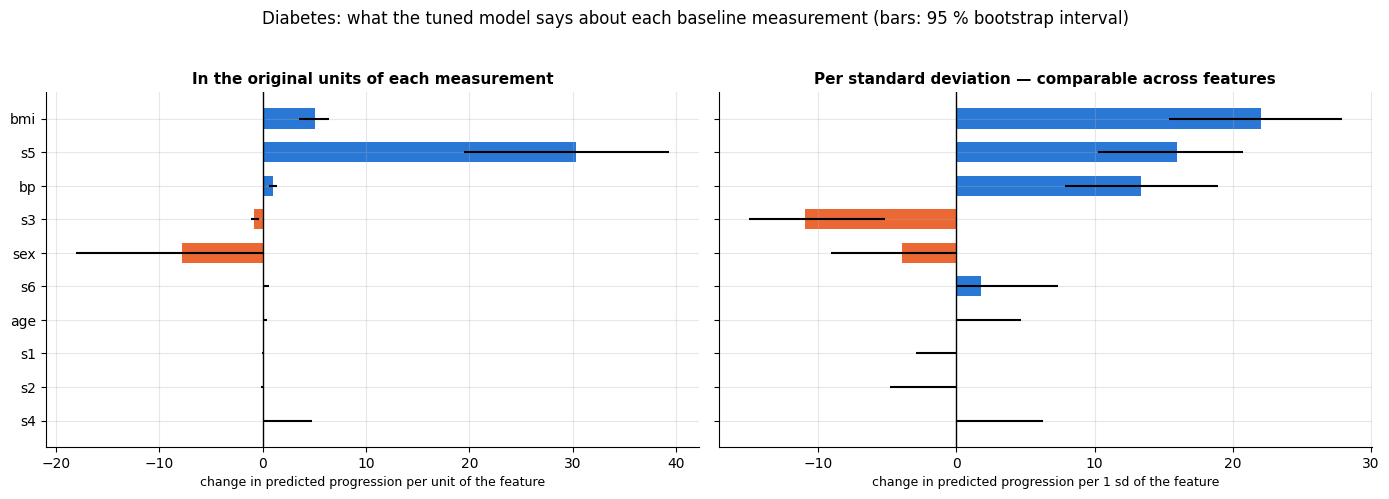

,per unit,2.5 %,97.5 %,per 1 sd,sd 2.5 %,sd 97.5 %,selected in % of resamples
bmi,5.03,3.51,6.38,22.00,15.36,27.91,100.00
s5,30.34,19.46,39.37,15.97,10.24,20.72,100.00
bp,0.96,0.56,1.36,13.34,7.85,18.95,100.00
s3,-0.86,-1.18,-0.40,-10.95,-15.03,-5.14,100.00
sex,-7.85,-18.11,-0.00,-3.92,-9.04,-0.00,93.33
s6,0.15,0.00,0.64,1.77,0.00,7.37,73.00
age,0.00,0.00,0.37,0.00,0.00,4.70,41.67
s1,-0.00,-0.08,-0.00,-0.00,-2.89,-0.00,29.67
s2,-0.00,-0.16,-0.00,-0.00,-4.79,-0.00,53.33
s4,0.00,0.00,4.80,0.00,0.00,6.28,58.33


In [32]:
sd_features = Xtr.std(ddof=0)      # each feature's training-set standard deviation (as StandardScaler computes it)
boot_coefs = []
for _ in range(300):               # 300 bootstrap refits of the final one-SE model
    idx = rng.integers(0, len(Xtr), len(Xtr))
    # .iloc[idx] selects the resampled rows by position
    m = make_pipeline(StandardScaler(), ElasticNet(alpha=float(one_se_row["param_elasticnet__alpha"]),
                                                   l1_ratio=float(one_se_row["param_elasticnet__l1_ratio"]),
                                                   max_iter=20000)).fit(Xtr.iloc[idx], ytr.iloc[idx])
    # per-unit coefficients: a standardised coefficient divided by the feature's standard deviation
    boot_coefs.append(m[-1].coef_ / sd_features.to_numpy())
boot_coefs = np.array(boot_coefs)                                  # shape (300, 10)
raw_units = final_model[-1].coef_ / sd_features.to_numpy()        # the final model's effect per original unit

boot_std = np.array(boot_coefs) * sd_features.to_numpy()          # same fits, per standard deviation
coef_case = pd.DataFrame({
    "per unit": raw_units,
    "2.5 %": np.percentile(boot_coefs, 2.5, axis=0),          # 95 % bootstrap percentile interval, per unit
    "97.5 %": np.percentile(boot_coefs, 97.5, axis=0),
    "per 1 sd": final_model[-1].coef_,
    "sd 2.5 %": np.percentile(boot_std, 2.5, axis=0),
    "sd 97.5 %": np.percentile(boot_std, 97.5, axis=0),
    # the mean of a True/False array is the share of True: how often the coefficient is non-zero
    "selected in % of resamples": 100 * (np.abs(boot_coefs) > 1e-8).mean(axis=0),
}, index=feature_names).sort_values("per 1 sd", key=np.abs, ascending=False)      # largest |effect| first

fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
o = coef_case.iloc[::-1]           # [::-1] reverses the rows, so barh draws the largest effect at the top
for ax, (val, lo, hi, title, xlabel) in zip(axes, [
        ("per unit", "2.5 %", "97.5 %", "In the original units of each measurement",
         "change in predicted progression per unit of the feature"),
        ("per 1 sd", "sd 2.5 %", "sd 97.5 %", "Per standard deviation — comparable across features",
         "change in predicted progression per 1 sd of the feature")]):
    # blue bars for positive effects, orange for negative ones
    ax.barh(o.index, o[val], color=[PALETTE[0] if v > 0 else PALETTE[1] for v in o[val]], height=0.6)
    ax.hlines(np.arange(len(o)), o[lo], o[hi], color="black", lw=1.5)     # one line per bar: its bootstrap interval
    ax.axvline(0, color="black", lw=1)
    ax.set_xlabel(xlabel, fontsize=9)
    ax.set_title(title, fontsize=11)
fig.suptitle("Diabetes: what the tuned model says about each baseline measurement (bars: 95 % bootstrap interval)",
             y=1.03)
plt.tight_layout()
plt.show()
display(coef_case.round(2))

Read the left panel in units, not in rank order. Its largest number, about +30 for `s5`,
looks dramatic only because `s5` is a *logarithm* of the serum triglyceride level, so one
"unit" is a factor of $e$ — a huge change. The clinically legible one is `bmi`: **+5
progression points per kg/m²**, with a 95 % bootstrap interval of roughly 3.5 to 6.5. The
right panel puts the features on the common footing of section 3.1 — one standard deviation
each — and there `bmi` is the strongest single predictor (about 22 points per sd), ahead of
`s5` and blood pressure. Blood pressure
adds about one point per mmHg, and `sex` (coded 1/2 here) shifts the prediction by about
−8 points. Several serum measurements are dropped in most resamples — `s1` and `s2`, the
collinear pair of section 4.2, survive in only a third to a half of them, exactly the
$\ell_1$ instability demonstrated in 9.4, so neither belongs in a sentence that begins
"the model says that cholesterol …". The intervals are wide throughout: with 331 patients,
"between 3.5 and 6.5 points per kg/m²" is the honest statement, not "5.0".

> **What you would tell a clinician.** *"From ten routine baseline measurements the model
> predicts a patient's disease progression one year later with a typical error of about 42
> points on a scale that runs from 25 to 346. That is a third better than guessing the
> study average, and it explains about half of the variation between patients — useful for
> ranking who to follow up, not precise enough to decide anything about an individual on
> its own. Body-mass index and triglycerides carry most of the signal: one extra kg/m² of
> BMI goes with about five more points of progression, all else being equal. These are
> associations measured in 442 patients from a single study, not causal effects — helping a
> patient lose weight is not guaranteed to move their progression by five points — and
> several blood measurements are so strongly correlated that the model cannot separate
> their contributions at all. Use it to flag patients who may deserve closer follow-up, and
> re-fit it on your own population before you trust the numbers."*

### 11.5 A second dataset: California housing

One dataset is never enough to judge a method. The **California housing** data (Pace &
Barry, 1997) are the opposite case: 20 640 census districts, eight features, and a strong
non-linear structure. The loader downloads the real data when you are online; **offline it
falls back to a synthetic stand-in with the same columns** (it prints a note), so the
numbers below are not the published ones, but the qualitative comparison holds. We
subsample 2 500 districts to keep the runtime short.

In [33]:
housing = load_california_housing()      # course helper: real data via scikit-learn, or a synthetic stand-in offline
X_house_full, y_house_full = housing.data, housing.target       # a DataFrame of 8 features and a Series target
subset = rng.choice(len(X_house_full), 2500, replace=False)     # 2500 distinct random row positions
# .iloc picks those rows; reset_index(drop=True) renumbers them 0..2499
X_house, y_house = X_house_full.iloc[subset].reset_index(drop=True), y_house_full.iloc[subset].reset_index(drop=True)
print(f"California housing: {X_house_full.shape[0]} districts available, using {len(X_house)}; features = {list(X_house.columns)}")
print(f"target (median house value, in 100k$): mean {y_house.mean():.2f}, std {y_house.std():.2f}")

# dict comprehension: the five named entries of case_models (cross_val_score fits fresh copies of them)
house_models = {k: case_models[k] for k in ["mean baseline", "least squares", "ridge (tuned)", "splines + ridge", "gradient boosting"]}
house_rows = []
for model_name, model in house_models.items():
    t0 = time.time()
    rmse = -cross_val_score(model, X_house, y_house, cv=kf, scoring="neg_root_mean_squared_error")
    # pre-formatted "mean ± standard error" strings
    house_rows.append({"model": model_name, "CV RMSE": f"{rmse.mean():.3f} ± {rmse.std(ddof=1) / np.sqrt(len(rmse)):.3f}",
                       "time (s)": f"{time.time() - t0:.1f}"})
pd.DataFrame(house_rows).set_index("model")

[course_utils] could not download California housing (URLError); using a synthetic stand-in with the same columns. Results will differ from the real data.
California housing: 20640 districts available, using 2500; features = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']
target (median house value, in 100k$): mean 2.52, std 1.20


,CV RMSE,time (s)
model,,
mean baseline,1.201 ± 0.010,0.0
least squares,0.691 ± 0.015,0.0
ridge (tuned),0.691 ± 0.015,0.1
splines + ridge,0.636 ± 0.007,0.2
gradient boosting,0.492 ± 0.006,0.7


Here the ranking is completely different: a straight line in the raw features is clearly
beaten by splines (non-linear effects of income and age) and by gradient boosting (which
also captures the interaction between latitude and longitude — i.e. *location*). Learning
curves separate the two reasons a model can be behind.

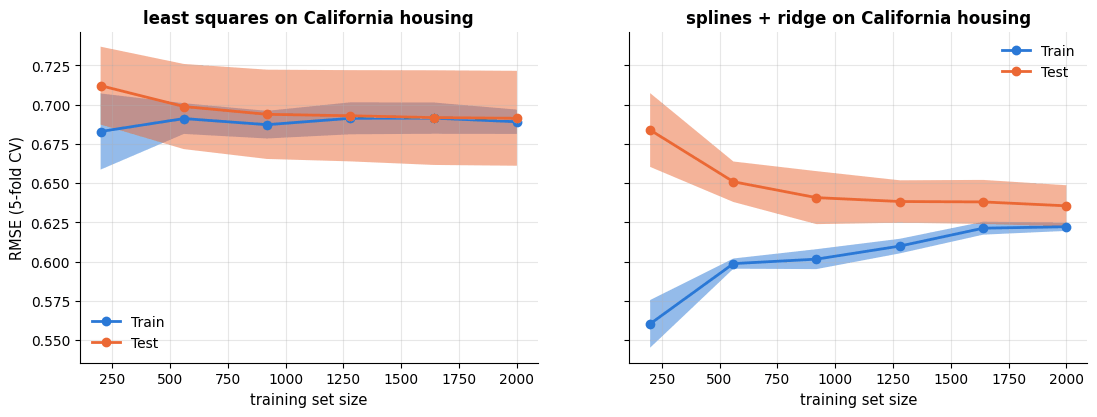

In [34]:
from sklearn.model_selection import LearningCurveDisplay      # computes and plots a learning curve in one call

fig, axes = plt.subplots(1, 2, figsize=(13, 4.3), sharey=True)
for ax, name in zip(axes, ["least squares", "splines + ridge"]):
    # trains on 6 growing fractions (10 % to 100 %) of each CV training fold and plots training and validation scores
    # (score_type="both"); negate_score=True turns the negated RMSE back into RMSE;
    # std_display_style="fill_between" shades ± 1 standard deviation over the folds
    LearningCurveDisplay.from_estimator(house_models[name], X_house, y_house, train_sizes=np.linspace(0.1, 1.0, 6), cv=kf,
                                        scoring="neg_root_mean_squared_error", negate_score=True, score_type="both",
                                        ax=ax, line_kw={"marker": "o"}, std_display_style="fill_between")
    ax.set_title(f"{name} on California housing")
    ax.set_xlabel("training set size")
    ax.set_ylabel("")              # remove the automatic label; one shared label is set below
axes[0].set_ylabel("RMSE (5-fold CV)")
plt.show()

The straight-line model's two curves meet almost immediately at a high error: pure **bias**
— more data cannot help, better features or a more flexible model can. The spline model has
a lower plateau and a small, closing gap: some variance, mostly gone by a few thousand rows.
(Gradient boosting would show a larger gap that keeps closing — variance that more data
would reduce; notebook 10 takes it from here.)

> **The transferable lesson.** The same seven-line pipeline gave a *different* answer on
> the two datasets: on 442 noisy patients the simplest regularised linear model is the
> right choice and everything else is a tie; on 2 500 districts with genuine non-linear
> structure, the feature basis is what matters. Neither conclusion could be guessed in
> advance — which is why the baseline, the cross-validated comparison and the learning
> curve come *before* the model selection, not after it.

## Summary

- The linear model $\hat y = \mathbf{w}^\top\mathbf{x} + b$ is fitted by least squares,
  which is maximum likelihood under Gaussian noise. The solution is the **orthogonal
  projection** of $\mathbf{y}$ onto the column space of $\mathbf{X}$, characterised by the
  **normal equations** $\mathbf{X}^\top\mathbf{X}\boldsymbol{\theta} = \mathbf{X}^\top\mathbf{y}$.
- Solve them directly (`lstsq`, `LinearRegression`; $O(nd^2)$) when the data fit in memory;
  use (mini-batch) **gradient descent** for huge or streaming data — on **standardised**
  features, because the **condition number** governs both the stable learning rate and the
  speed of convergence.
- Coefficients are effects per unit *holding other features fixed*; compare them
  standardised, quantify uncertainty analytically or by the **bootstrap**, and check the
  **VIF** before interpreting coefficients of correlated features.
- **Diagnostics**: residuals vs. fitted (curve → non-linearity, funnel → heteroscedasticity),
  Q–Q plot (tails), leverage and Cook's distance (influential rows).
- Report **RMSE** (or MAE for heavy tails) with a mean baseline and $R^2$; use Huber or
  RANSAC when gross outliers are present.
- Polynomial and especially **spline** features fit curves with a linear model; interactions
  add products of features.
- **Ridge** ($\ell_2$) shrinks low-variance directions and stabilises collinear problems;
  **lasso** ($\ell_1$) produces sparse models through soft thresholding; **elastic net**
  mixes both. Choose $\lambda$ by cross-validation; standardise first; which penalty wins
  depends on whether the truth is sparse or dense.
- **GLMs** generalise the same linear predictor to counts (Poisson, log link) and binary
  targets (logistic regression, notebook 7).
- All four estimators share one hypothesis space and therefore one set of failure modes:
  they cannot bend (fix the *basis*, not the algorithm), their coefficients become
  meaningless under collinearity long before their predictions do, and $\ell_1$ selection
  inside a correlated group is close to arbitrary (section 9).
- **Tune in this order**: standardise, choose the feature basis, then `alpha` on a log grid,
  then `l1_ratio`. `alpha` interacts with the basis and with `l1_ratio`, so tune those pairs
  jointly on a 2-D grid; the solver, `tol` and `max_iter` change the runtime, not the answer.
  Flat validation curves are the rule rather than the exception — take the one-standard-error
  choice (section 10).
- On real data (section 11) the discipline matters more than the model: a mean baseline
  first, cross-validated comparison inside pipelines second, tuning third, and a held-out
  test set plus residual diagnostics before any coefficient is quoted — in units, with an
  interval, and with the collinear features flagged as uninterpretable.

| Task | Tool |
|---|---|
| Plain least squares | `LinearRegression()`; `np.linalg.lstsq(X, y)` |
| Large $n$ / streaming | `SGDRegressor` on standardised features; mini-batch GD |
| Regularised linear model | `Ridge`, `Lasso`, `ElasticNet`; `RidgeCV`, `LassoCV`, `ElasticNetCV` to tune `alpha` |
| Regularisation path | `lasso_path`, `enet_path`; `Ridge` in a loop |
| Non-linear effects | `SplineTransformer`, `PolynomialFeatures` (+ `Ridge`) |
| Coefficient uncertainty | bootstrap; analytic SEs by hand or `statsmodels.OLS` |
| Diagnostics | residual / Q–Q / influence plots, `PredictionErrorDisplay`, VIF by hand |
| Metrics | `root_mean_squared_error`, `mean_absolute_error`, `mean_absolute_percentage_error`, `r2_score` |
| Outliers | `HuberRegressor`, `RANSACRegressor` |
| Tuning one parameter | validation curve: `cross_val_score` on a log grid, mean ± SE, one-SE rule |
| Tuning two interacting parameters | `GridSearchCV` + a 2-D heat-map of CV score (section 10.4) |
| Counts, positive targets | `PoissonRegressor`, `GammaRegressor`, `TweedieRegressor` |

**Next steps:** notebook 7 (logistic regression and classification metrics) is the same
model with a logit link and cross-entropy loss; notebook 11 (SVMs) replaces the squared loss
by the hinge loss and adds kernels; notebook 12 tunes `alpha` and preprocessing jointly;
and the mini-batch gradient descent you implemented here is also how neural networks are trained — the natural continuation of this notebook, covered in a dedicated deep-learning course.

## Exercises

### Exercise 1 — Ridge as augmented least squares (easy)
Show that the ridge solution equals ordinary least squares on the augmented data
$\tilde{\mathbf{X}} = \begin{pmatrix}\mathbf{X}\\ \sqrt{\lambda}\,\mathbf{I}\end{pmatrix}$,
$\tilde{\mathbf{y}} = \begin{pmatrix}\mathbf{y}\\ \mathbf{0}\end{pmatrix}$, first on paper
(expand $\|\tilde{\mathbf{y}} - \tilde{\mathbf{X}}\mathbf{w}\|^2$) and then numerically with
`np.linalg.lstsq` on the standardised diabetes data, comparing with `Ridge(alpha=10)`.

<details><summary>Solution sketch</summary>

$\|\tilde{\mathbf{y}} - \tilde{\mathbf{X}}\mathbf{w}\|^2 = \|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2 + \lambda\|\mathbf{w}\|^2$,
so the augmented least-squares problem *is* the ridge problem.
```py
X_aug = np.vstack([Xs, np.sqrt(10.0) * np.eye(10)]); y_aug = np.r_[yc, np.zeros(10)]
w_aug = np.linalg.lstsq(X_aug, y_aug, rcond=None)[0]
np.abs(w_aug - Ridge(alpha=10.0).fit(Xs, yd).coef_).max()      # ~1e-13
```
This is also how ridge can be fitted with any least-squares solver, including `lstsq`'s
stable QR/SVD route.
</details>

### Exercise 2 — Learning-rate schedules (easy)
Extend `LinearRegressionGD` with a decaying learning rate $\eta_t = \eta_0 / (1 + t / T)$
(with $t$ the update counter). Compare SGD with a constant and with a decaying rate on the
standardised diabetes data over 300 epochs: which one ends closer to the least-squares
coefficients?

<details><summary>Solution sketch</summary>

Add a counter in `fit` and multiply the step by `1 / (1 + step / T)` with `T` around one
epoch's worth of updates. The decaying rate removes the residual fluctuation of SGD and
ends within a fraction of a unit of the OLS coefficients; the constant rate keeps
bouncing. This is the Robbins–Monro condition in action.
</details>

### Exercise 3 — Multicollinearity surgery (medium)
Drop `s2` from the diabetes features and refit. Recompute the VIFs and the analytic
standard errors of `s1`. Then instead of dropping, replace `s1` and `s2` by their average
and their difference. How do the test RMSE (5-fold CV) and the standard errors change in
each case?

<details><summary>Solution sketch</summary>

Dropping `s2` reduces the VIF of `s1` to about 3 and its standard error by a factor of
roughly 4, while the CV RMSE is essentially unchanged — the information was redundant. The
average/difference reparametrisation gives the same predictions as the original model
(it is an invertible linear transformation) but well-conditioned coefficients: the average
is precisely estimated, the difference is not.
</details>

### Exercise 4 — Stability of lasso selection (medium)
Bootstrap the diabetes data 200 times; on each resample fit `make_pipeline(StandardScaler(),
Lasso(alpha=1.0))` and record which coefficients are non-zero. Plot the selection frequency
of each feature. Which features are selected almost always, which almost never, and what
happens to the pair `s1`/`s2`?

<details><summary>Solution sketch</summary>

`bmi`, `s5`, `bp` and `sex` are selected in nearly every resample; `age` and `s6` rarely;
`s1`/`s2` alternate — in a given resample the lasso keeps one of the two, which one depends
on the sample. Selection frequencies (Meinshausen & Bühlmann's *stability selection* idea)
are a far more honest summary than the single selected subset.
</details>

### Exercise 5 — Poisson regression on the churn support tickets (hard)
The churn data (`load_churn()`) contain the count `support_tickets`. Model it from
`internet_service`, `tech_support`, `contract` and `tenure_months` with (a) least squares and
(b) `PoissonRegressor`, inside a `ColumnTransformer` pipeline with one-hot encoding. Compare
test RMSE and mean Poisson deviance, check for negative predictions, and interpret
$e^{w_j}$ for the `tech_support` coefficient. Then add `monthly_charges`: does it matter?

<details><summary>Solution sketch</summary>

Both models fit similarly on this data (the rates lie between 0.3 and 1.8, so the linear
model stays positive), but the Poisson coefficients are directly interpretable:
$e^{w_\text{tech\_support}} \approx 0.74$ means tech support lowers the expected number of
tickets by about a quarter; Fiber optic multiplies it by roughly 3 relative to DSL.
`monthly_charges` adds nothing once the service type is known. Use
`mean_poisson_deviance` as the metric — it is what the Poisson model optimises.
</details>

## References and further reading

### Textbooks

- James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). *An Introduction to Statistical Learning with Applications in Python*. Springer. (free at https://www.statlearning.com) — Chapter 3 (linear regression, diagnostics) and chapter 6 (ridge, lasso, the constraint-region figure) cover this notebook at the same level.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* (2nd ed.). Springer. (free) — Chapter 3 is the definitive treatment of linear methods for regression, including the SVD view of ridge and the LARS/lasso path.
- Boyd, S., & Vandenberghe, L. (2018). *Introduction to Applied Linear Algebra: Vectors, Matrices, and Least Squares*. Cambridge University Press. (free) — Chapters 12–15: least squares, its geometry and its regularised variants, with minimal prerequisites.
- Boyd, S., & Vandenberghe, L. (2004). *Convex Optimization*. Cambridge University Press. (free) — Chapter 9 explains the convergence rate of gradient descent in terms of the condition number.
- Deisenroth, M. P., Faisal, A. A., & Ong, C. S. (2020). *Mathematics for Machine Learning*. Cambridge University Press. (free) — Chapter 9 derives linear regression from the probabilistic (MLE and MAP) viewpoint.
- Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. (free) — Chapter 11 on linear regression and its Bayesian interpretation; chapter 12 on generalised linear models.
- Efron, B., & Hastie, T. (2016). *Computer Age Statistical Inference*. Cambridge University Press. (free) — Chapters 7, 10 and 16 on ridge, the bootstrap and sparse modelling from a statistician's perspective.

### Papers

- Hoerl, A. E., & Kennard, R. W. (1970). Ridge regression: biased estimation for nonorthogonal problems. *Technometrics*, 12(1), 55–67. — The original ridge paper; the motivation is exactly the ill-conditioning of section 4.2.
- Tibshirani, R. (1996). Regression shrinkage and selection via the lasso. *Journal of the Royal Statistical Society: Series B*, 58(1), 267–288.
- Zou, H., & Hastie, T. (2005). Regularization and variable selection via the elastic net. *Journal of the Royal Statistical Society: Series B*, 67(2), 301–320.
- Efron, B., Hastie, T., Johnstone, I., & Tibshirani, R. (2004). Least angle regression. *The Annals of Statistics*, 32(2), 407–499. — Introduces the diabetes data and shows that the lasso path is piecewise linear.
- Friedman, J., Hastie, T., & Tibshirani, R. (2010). Regularization paths for generalized linear models via coordinate descent. *Journal of Statistical Software*, 33(1), 1–22. — The coordinate-descent algorithm implemented in section 7.2 (and in scikit-learn).
- Efron, B. (1979). Bootstrap methods: another look at the jackknife. *The Annals of Statistics*, 7(1), 1–26.
- Huber, P. J. (1964). Robust estimation of a location parameter. *The Annals of Mathematical Statistics*, 35(1), 73–101. — The Huber loss.
- Fischler, M. A., & Bolles, R. C. (1981). Random sample consensus: a paradigm for model fitting with applications to image analysis and automated cartography. *Communications of the ACM*, 24(6), 381–395. — RANSAC.
- Cook, R. D. (1977). Detection of influential observation in linear regression. *Technometrics*, 19(1), 15–18. — Cook's distance.
- Nelder, J. A., & Wedderburn, R. W. M. (1972). Generalized linear models. *Journal of the Royal Statistical Society: Series A*, 135(3), 370–384. — The GLM framework of section 8.
- Robbins, H., & Monro, S. (1951). A stochastic approximation method. *The Annals of Mathematical Statistics*, 22(3), 400–407. — The origin of stochastic gradient descent and of decaying learning rates.
- Bottou, L., Curtis, F. E., & Nocedal, J. (2018). Optimization methods for large-scale machine learning. *SIAM Review*, 60(2), 223–311. — A thorough modern survey of SGD and its variants.
- Stigler, S. M. (1981). Gauss and the invention of least squares. *The Annals of Statistics*, 9(3), 465–474. — The history behind section 1.
- Pace, R. K., & Barry, R. (1997). Sparse spatial autoregressions. *Statistics & Probability Letters*, 33(3), 291–297. — The California housing data.

### Documentation and online resources

- scikit-learn user guide, *Linear models* (least squares, ridge, lasso, elastic net, robust and generalised linear regression) — https://scikit-learn.org/stable/modules/linear_model.html
- scikit-learn user guide, *Preprocessing data* (spline and polynomial features) — https://scikit-learn.org/stable/modules/preprocessing.html
- scikit-learn user guide, *Metrics and scoring: regression metrics* — https://scikit-learn.org/stable/modules/model_evaluation.html
- statsmodels documentation, *Linear regression* (classical inference tables, diagnostics) — https://www.statsmodels.org/stable/regression.html
- NumPy documentation, `numpy.linalg.lstsq` — https://numpy.org/doc/stable/reference/generated/numpy.linalg.lstsq.html